# GLFTMM Result Curves

Use `sim/report.py` to discover result folders and plot the curve for every folder.

In [1]:
from __future__ import annotations

import importlib
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

REPO_ROOT = Path("/home/kang/glftmm_lot")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

report_tools = importlib.import_module("sim.report")

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.max_rows", 200)

Edit the variables below when you want a different symbol, date range, folder keyword, or plotting density.

In [2]:
with open(REPO_ROOT / "config/config.json", "r", encoding="utf-8") as fh:
    CONFIG = json.load(fh)

ROOT_DIR = Path(CONFIG["paths"]["output_dir"])
SYMBOL = CONFIG.get("symbols", ["BTCUSDT"])[0]

# Use None for the full available range. Date format can be YYYY-MM-DD or YYYYMMDD.
SRT = None
END = None
EXCLUDE_DATE = None

# Optional folder-path substring filter, for example "md1" or "pg10x50".
KEYWORD = None

# Larger EVERY is faster and lighter. Set lower for smoother intraday curves.
EVERY = 600

# PNL_ONLY=True plots only total PnL curves. False plots price/inventory/PnL/volume panels.
PNL_ONLY = False
NORMALIZE = False

# Plot folders in batches so each chart remains readable.
BATCH_SIZE = 6
NUM_WORKERS = 4

# Set to an integer while testing, for example 5. Use None for every discovered folder.
MAX_FOLDERS = None

ROOT_DIR, SYMBOL

(PosixPath('/data/users/kang/backtest/glftmm_lot/result'), 'BTCUSDT')

Discover every leaf folder that contains matching parquet reports.

In [3]:
folders, counts = report_tools.get_folders_with_counts(
    ROOT_DIR,
    SYMBOL,
    srt=SRT,
    end=END,
    exclude_date=EXCLUDE_DATE,
    keyword=KEYWORD,
)

folder_df = pd.DataFrame(
    {
        "run_id": np.arange(len(folders), dtype=int),
        "file_count": counts,
        "folder": folders,
    }
)

def run_name(folder: str | Path) -> str:
    path = Path(folder)
    if path.name == "strat__all" and path.parent.name:
        return path.parent.name
    return path.name

if not folder_df.empty:
    folder_df.insert(1, "run_name", folder_df["folder"].map(run_name))

print(f"found {len(folder_df)} folders under {ROOT_DIR}")
display(folder_df)

if folder_df.empty:
    raise FileNotFoundError(
        f"no report parquet folders found under {ROOT_DIR} for symbol={SYMBOL}, keyword={KEYWORD}"
    )

found 80 folders under /data/users/kang/backtest/glftmm_lot/result


,run_id,run_name,file_count,folder
0,0,sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__mon100__moq0__md0__irbbo_imbalance__ink__vnsigma__ocu...,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...
1,1,sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__mon100__moq0__md0__irbbo_imbalance__ink__vnsigma__ocu...,61,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...
2,2,sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__mon100__moq0__md0__irbbo_imbalance__ink__vnsigma__ocu...,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...
3,3,sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__mon100__moq0__md0__irbbo_imbalance__ink__vnsigma__ocu...,59,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...
4,4,sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__mon100__moq0__md0__irbbo_imbalance__ink__vnsigma__ocu...,57,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...
5,5,sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__mon100__moq0__md0__irbbo_imbalance__ink__vnsigma__ocu...,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...
6,6,sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__mon100__moq0__md0__irbbo_imbalance__ink__vnsigma__ocu...,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...
7,7,sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__mon100__moq0__md0__irbbo_imbalance__ink__vnsigma__ocu...,57,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...
8,8,sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__mon100__moq0__md0__irbbo_imbalance__ink__vnsigma__ocu...,56,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...
9,9,sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__mon100__moq0__md0__irbbo_imbalance__ink__vnsigma__ocu...,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...


Helper functions for selecting folders and calling `report_tools.report(...)`.

In [4]:
def choose_folders(
    indices: list[int] | tuple[int, ...] | None = None,
    contains: str | None = None,
    limit: int | None = MAX_FOLDERS,
) -> pd.DataFrame:
    df = folder_df.copy()
    if contains is not None:
        df = df[df["folder"].str.contains(contains, regex=False)]
    if indices is not None:
        wanted = list(indices)
        df = df[df["run_id"].isin(wanted)]
        df = df.set_index("run_id").reindex(wanted).dropna(subset=["folder"]).reset_index()
    if limit is not None:
        df = df.head(int(limit))
    return df.reset_index(drop=True)


def plot_folder_batch(
    df: pd.DataFrame,
    *,
    pnl_only: bool = PNL_ONLY,
    every: int = EVERY,
    normalize: bool = NORMALIZE,
) -> pd.DataFrame:
    if df.empty:
        raise ValueError("empty folder selection")

    folders_to_plot = df["folder"].tolist()
    labels = [f"{int(run_id):03d}" for run_id in df["run_id"]]

    stats = report_tools.report(
        folders_to_plot,
        every=every,
        pnl_only=pnl_only,
        srt=SRT,
        end=END,
        exclude_date=EXCLUDE_DATE,
        labels=labels,
        normalize=normalize,
        num_workers=NUM_WORKERS,
    )

    metrics = pd.DataFrame(stats)
    metrics.insert(0, "run_id", labels[: len(metrics)])
    metrics.insert(1, "file_count", df["file_count"].to_list()[: len(metrics)])
    metrics.insert(2, "folder", folders_to_plot[: len(metrics)])
    display(metrics)
    return metrics

Plot every discovered folder, split into batches.

batch 1: run_id 000..005


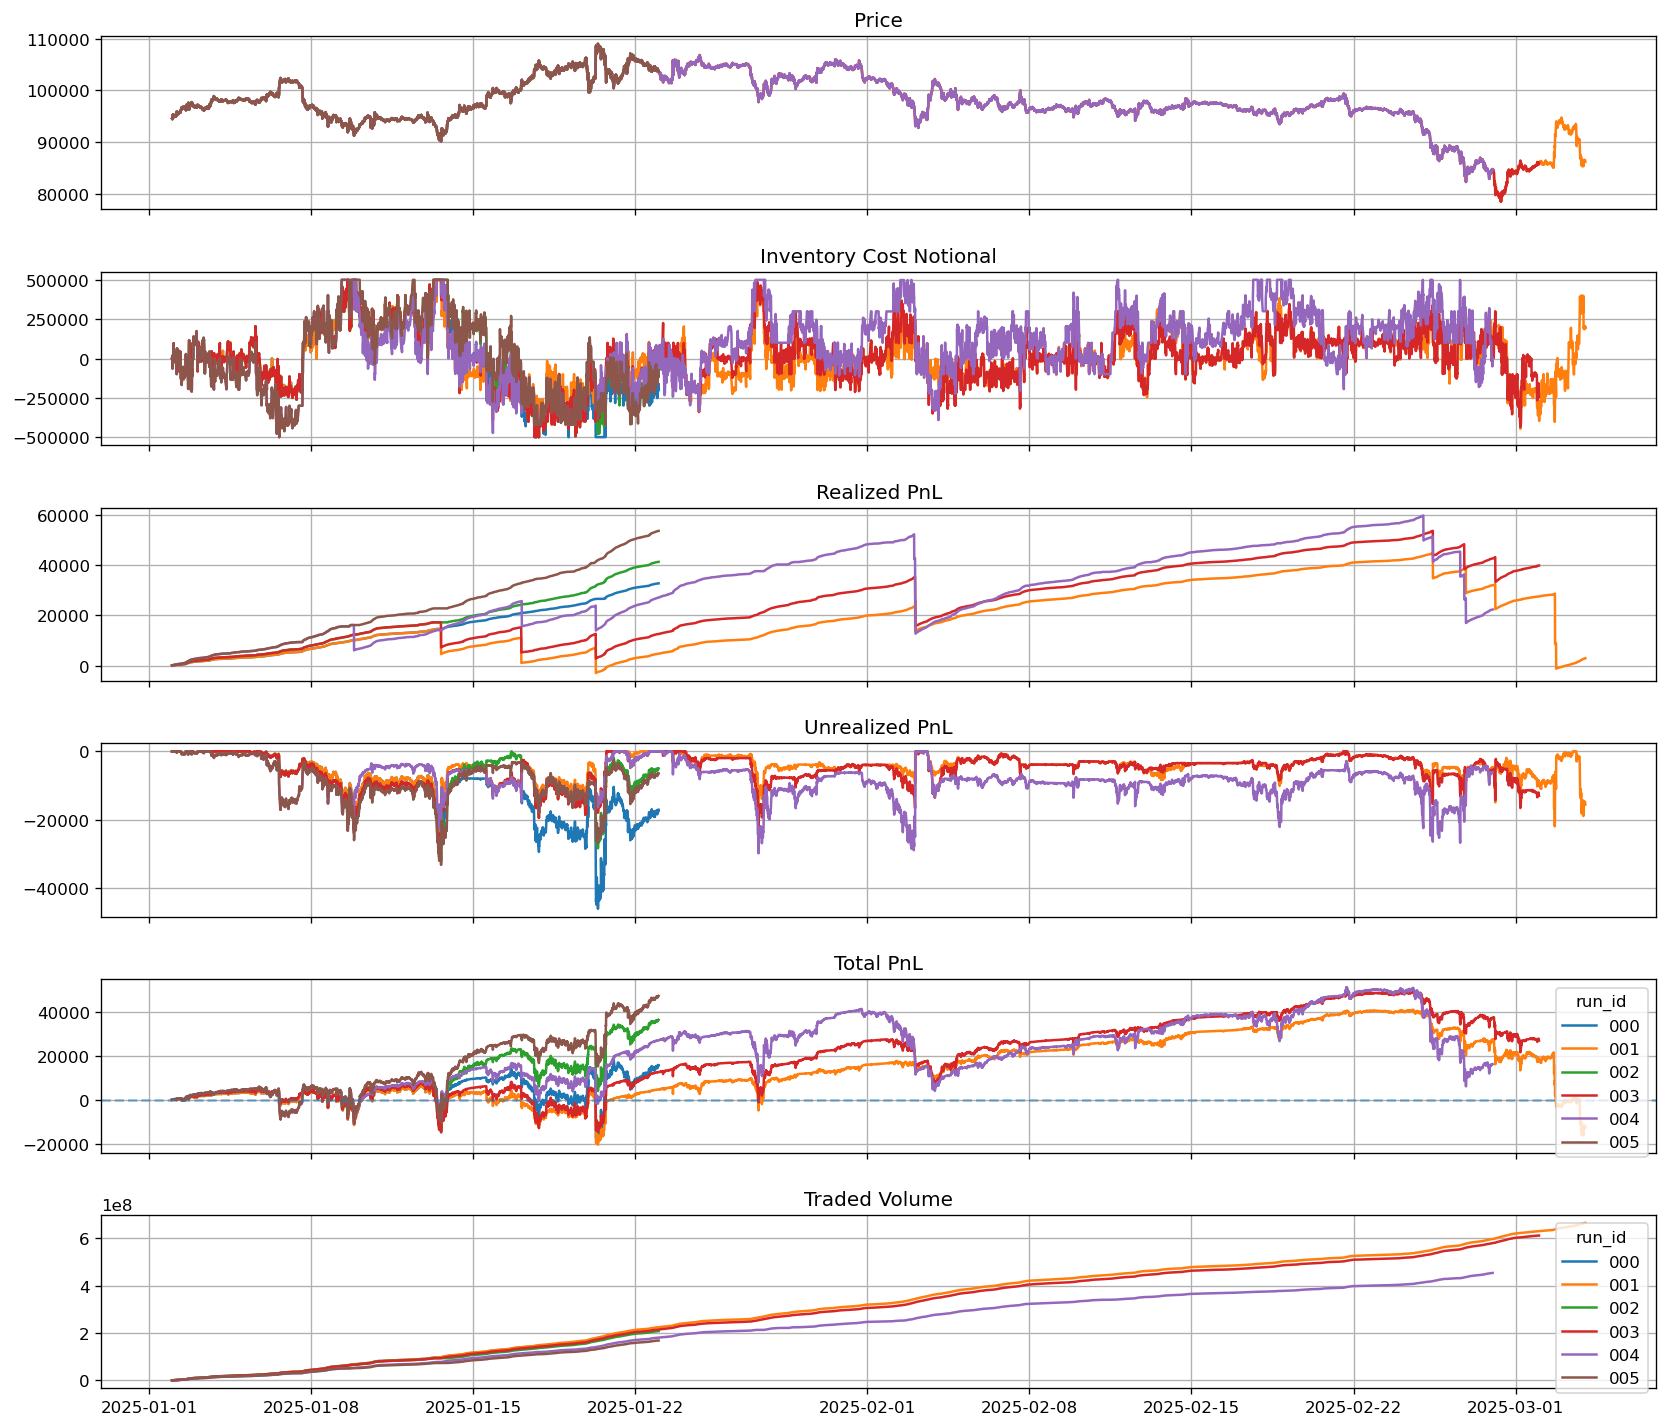

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,000,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,15756.528743,0.129735,22.776757,11613.802301,264524.752871,22.776757,0.129735,1.008064e+07,0.000074
1,001,61,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,-12594.076283,-0.049704,-1.584717,53190.106527,-84291.262954,-1.584717,-0.049704,1.091455e+07,-0.000019
2,002,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,36376.895770,0.333615,66.508434,9548.988986,635088.299813,66.508434,0.333615,9.894600e+06,0.000175
3,003,59,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,26948.818928,0.095670,7.326356,21793.113347,159664.102564,7.326356,0.095670,1.037322e+07,0.000044
4,004,57,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,16182.929819,0.039685,2.307460,38866.218003,89682.258896,2.307460,0.039685,7.944748e+06,0.000036
5,005,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,47268.695137,0.348477,67.172193,12183.993221,818425.541948,67.172193,0.348477,7.986552e+06,0.000280


batch 2: run_id 006..011


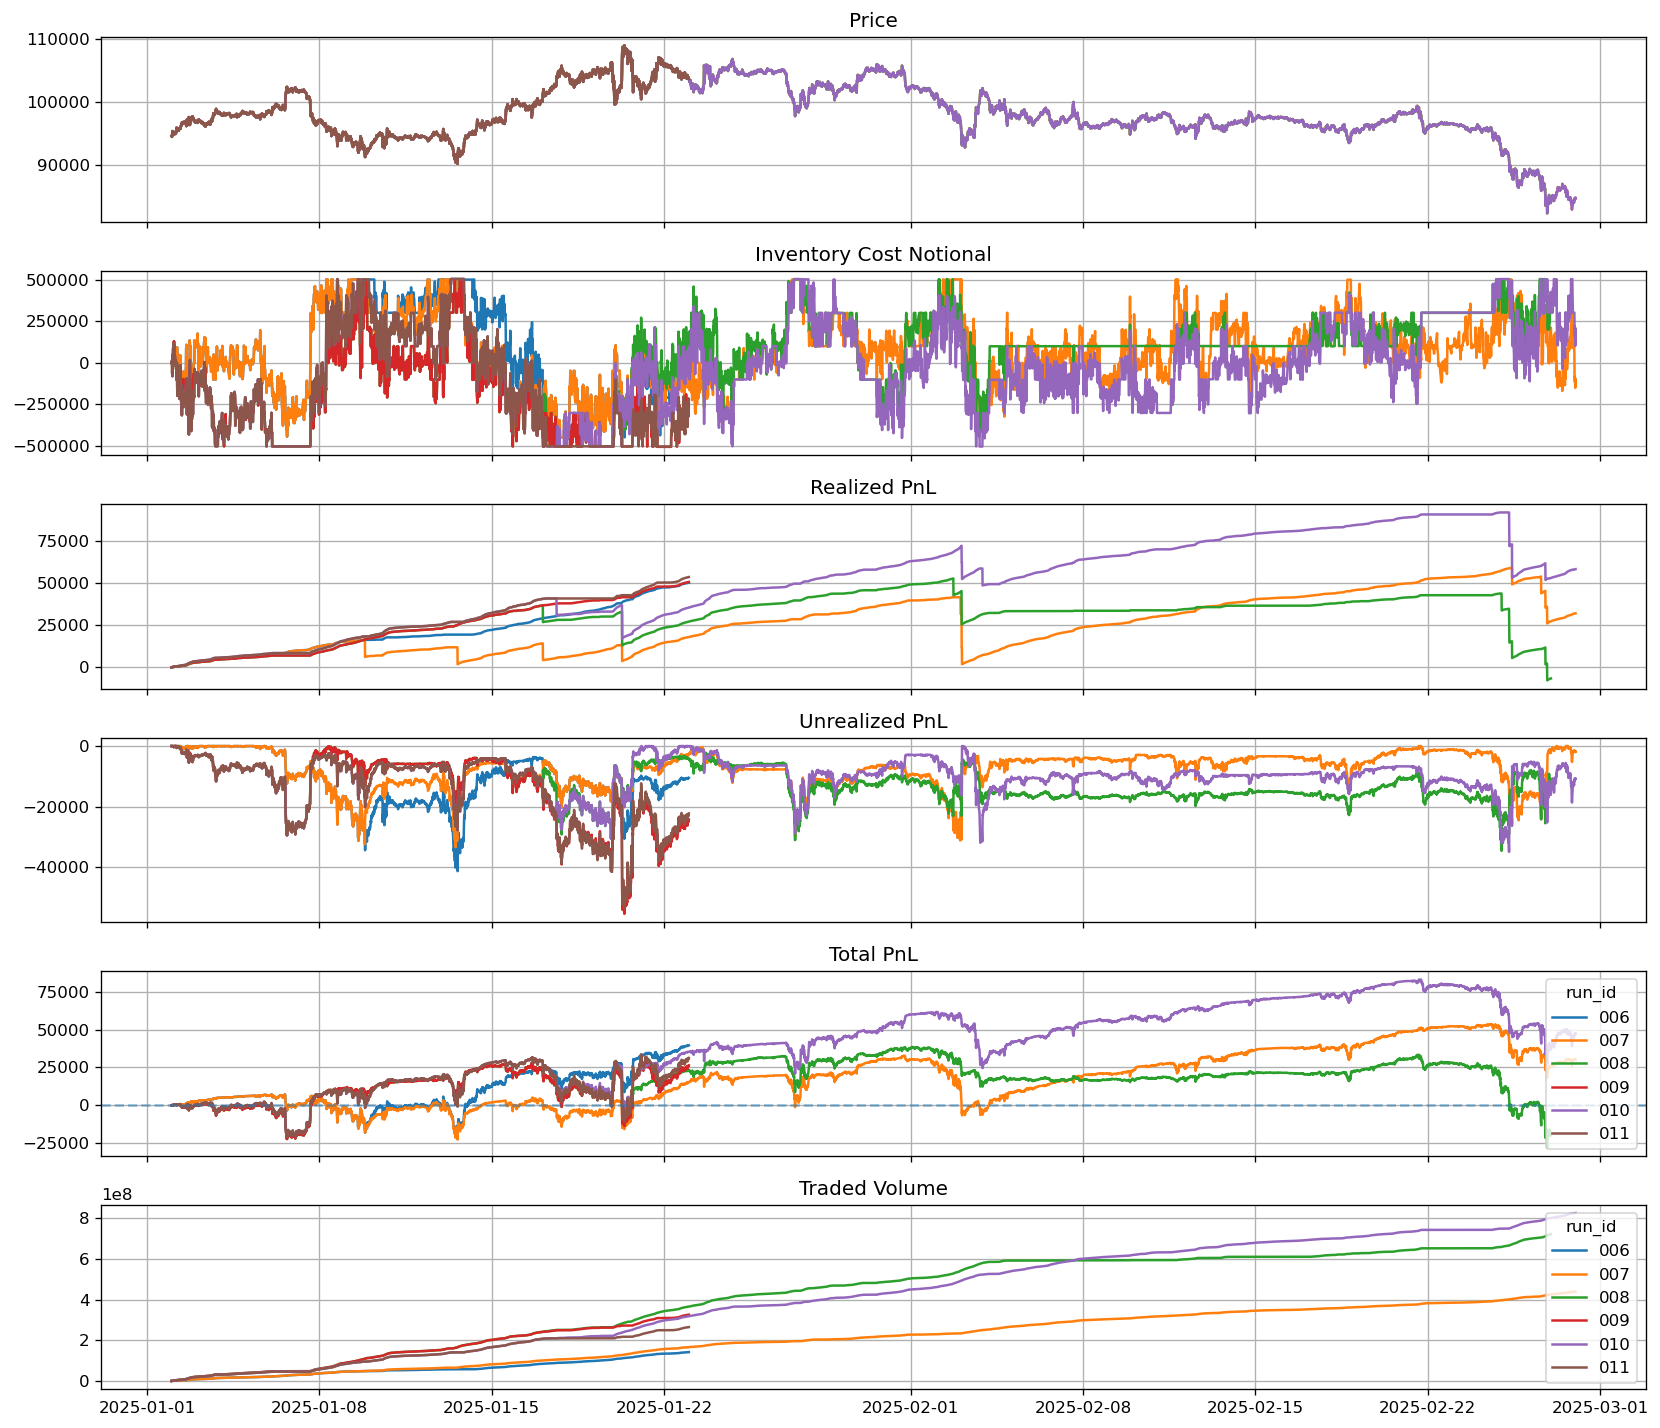

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,006,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,39655.883075,0.310523,36.759292,18374.569438,675436.169763,36.759292,0.310523,6.648930e+06,0.000280
1,007,57,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,30214.505126,0.083791,5.370374,33459.428693,179689.650785,5.370374,0.083791,7.681547e+06,0.000069
2,008,56,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,-18899.803222,-0.043855,-2.184710,56758.028246,-123999.853654,-2.184710,-0.043855,1.274077e+07,-0.000026
3,009,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,26425.195358,0.127737,23.146338,21004.689075,486181.626536,23.146338,0.127737,1.526477e+07,0.000081
4,010,57,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,47403.081775,0.096083,6.973369,43897.580909,306114.042168,6.973369,0.096083,1.438565e+07,0.000057
5,011,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,31318.776460,0.141892,26.716675,21094.718852,563580.746075,26.716675,0.141892,1.225584e+07,0.000118


batch 3: run_id 012..017


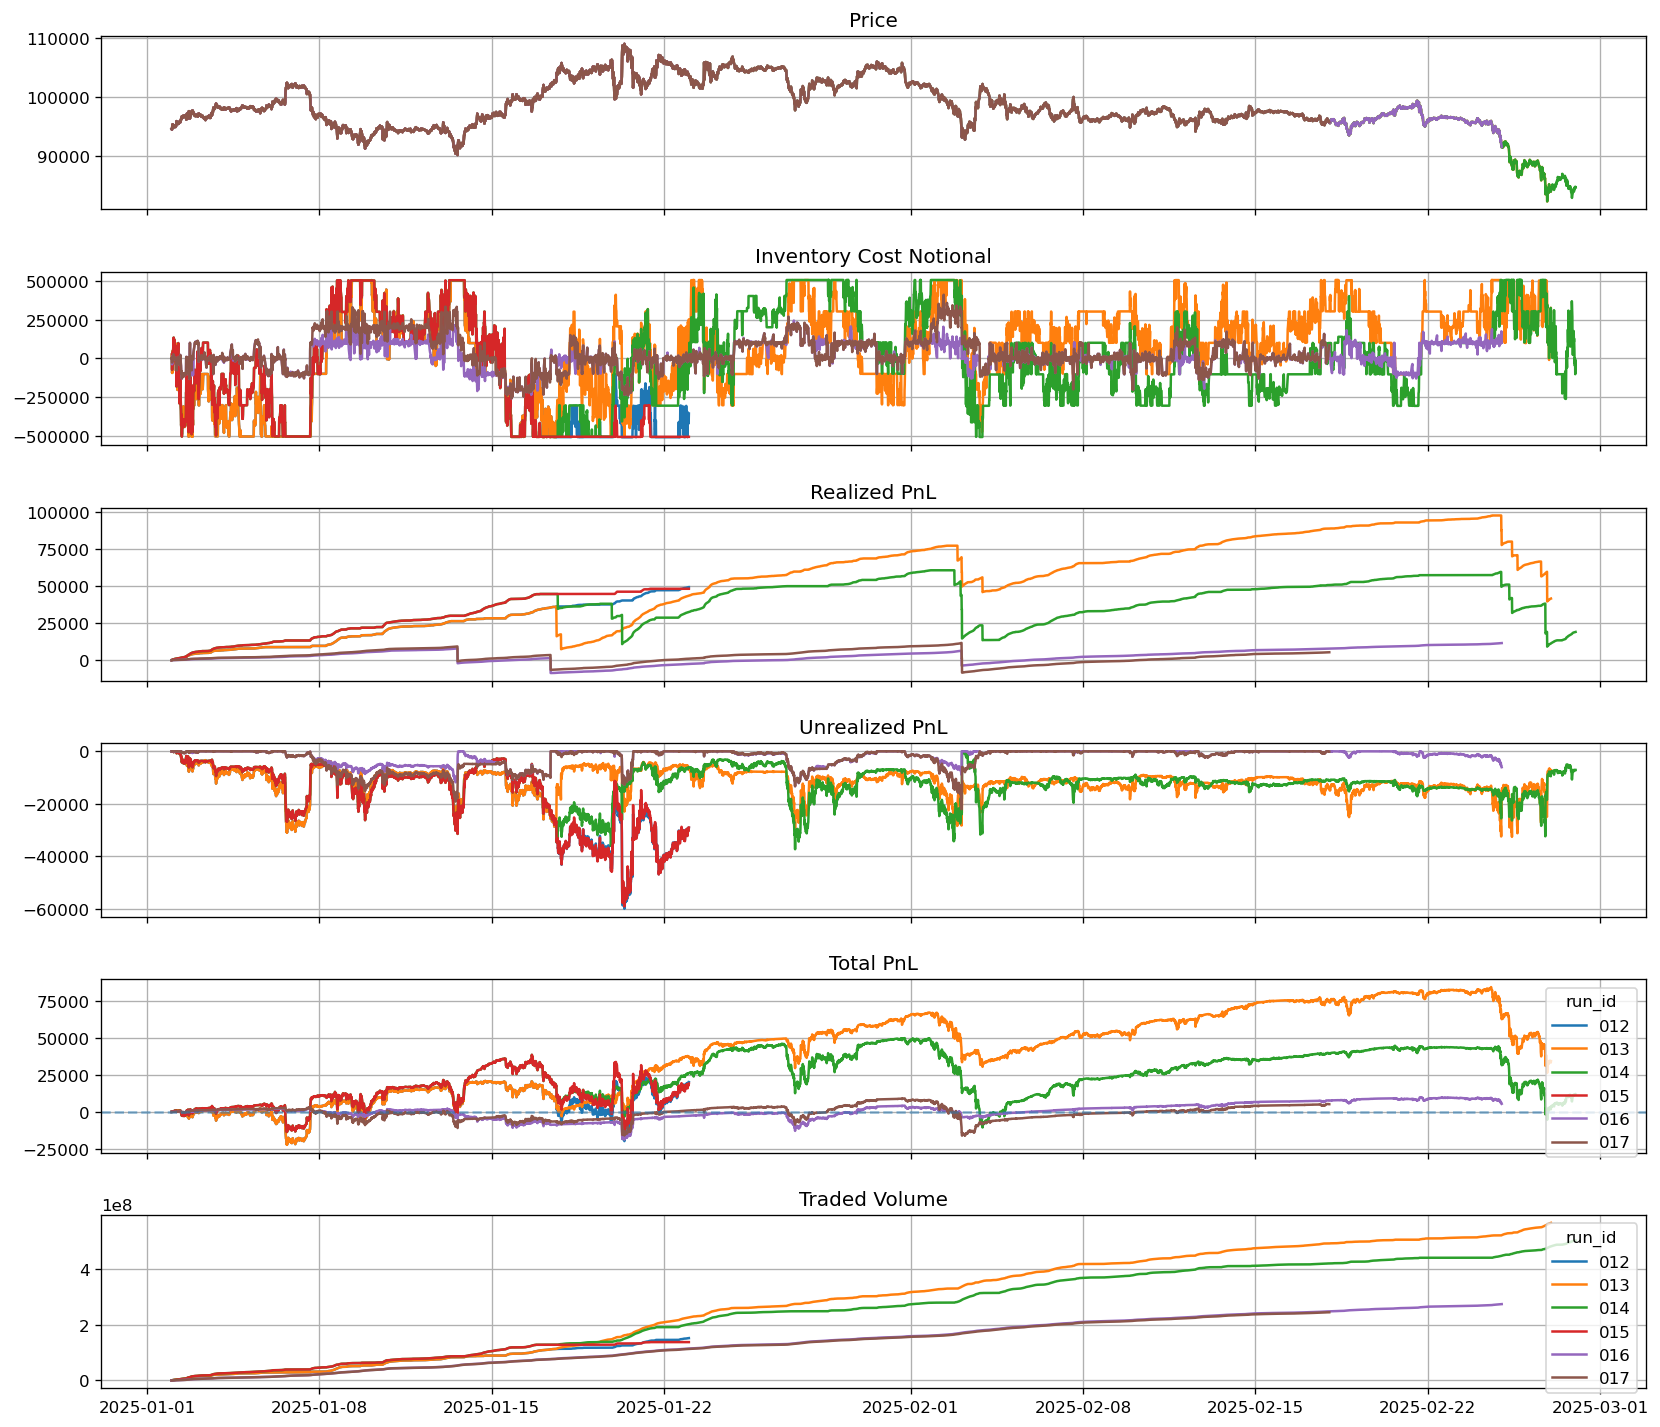

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,012,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,20156.765910,0.093449,17.961101,20711.959598,372009.607260,17.961101,0.093449,6.867934e+06,0.000133
1,013,56,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,34301.163620,0.075867,4.771512,48023.260982,229143.587439,4.771512,0.075867,1.001223e+07,0.000061
2,014,57,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,11929.540157,0.018860,1.174370,55346.785195,64997.584620,1.174370,0.018860,8.678709e+06,0.000024
3,015,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,19116.044180,0.074137,11.968513,26164.229960,313146.935344,11.968513,0.074137,6.060031e+06,0.000139
4,016,54,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,5478.851915,0.047133,2.719132,12291.556904,33422.362193,2.719132,0.047133,5.066514e+06,0.000020
5,017,47,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,5215.753661,0.037682,2.203644,15924.492009,35091.907699,2.203644,0.037682,5.201681e+06,0.000021


batch 4: run_id 018..023


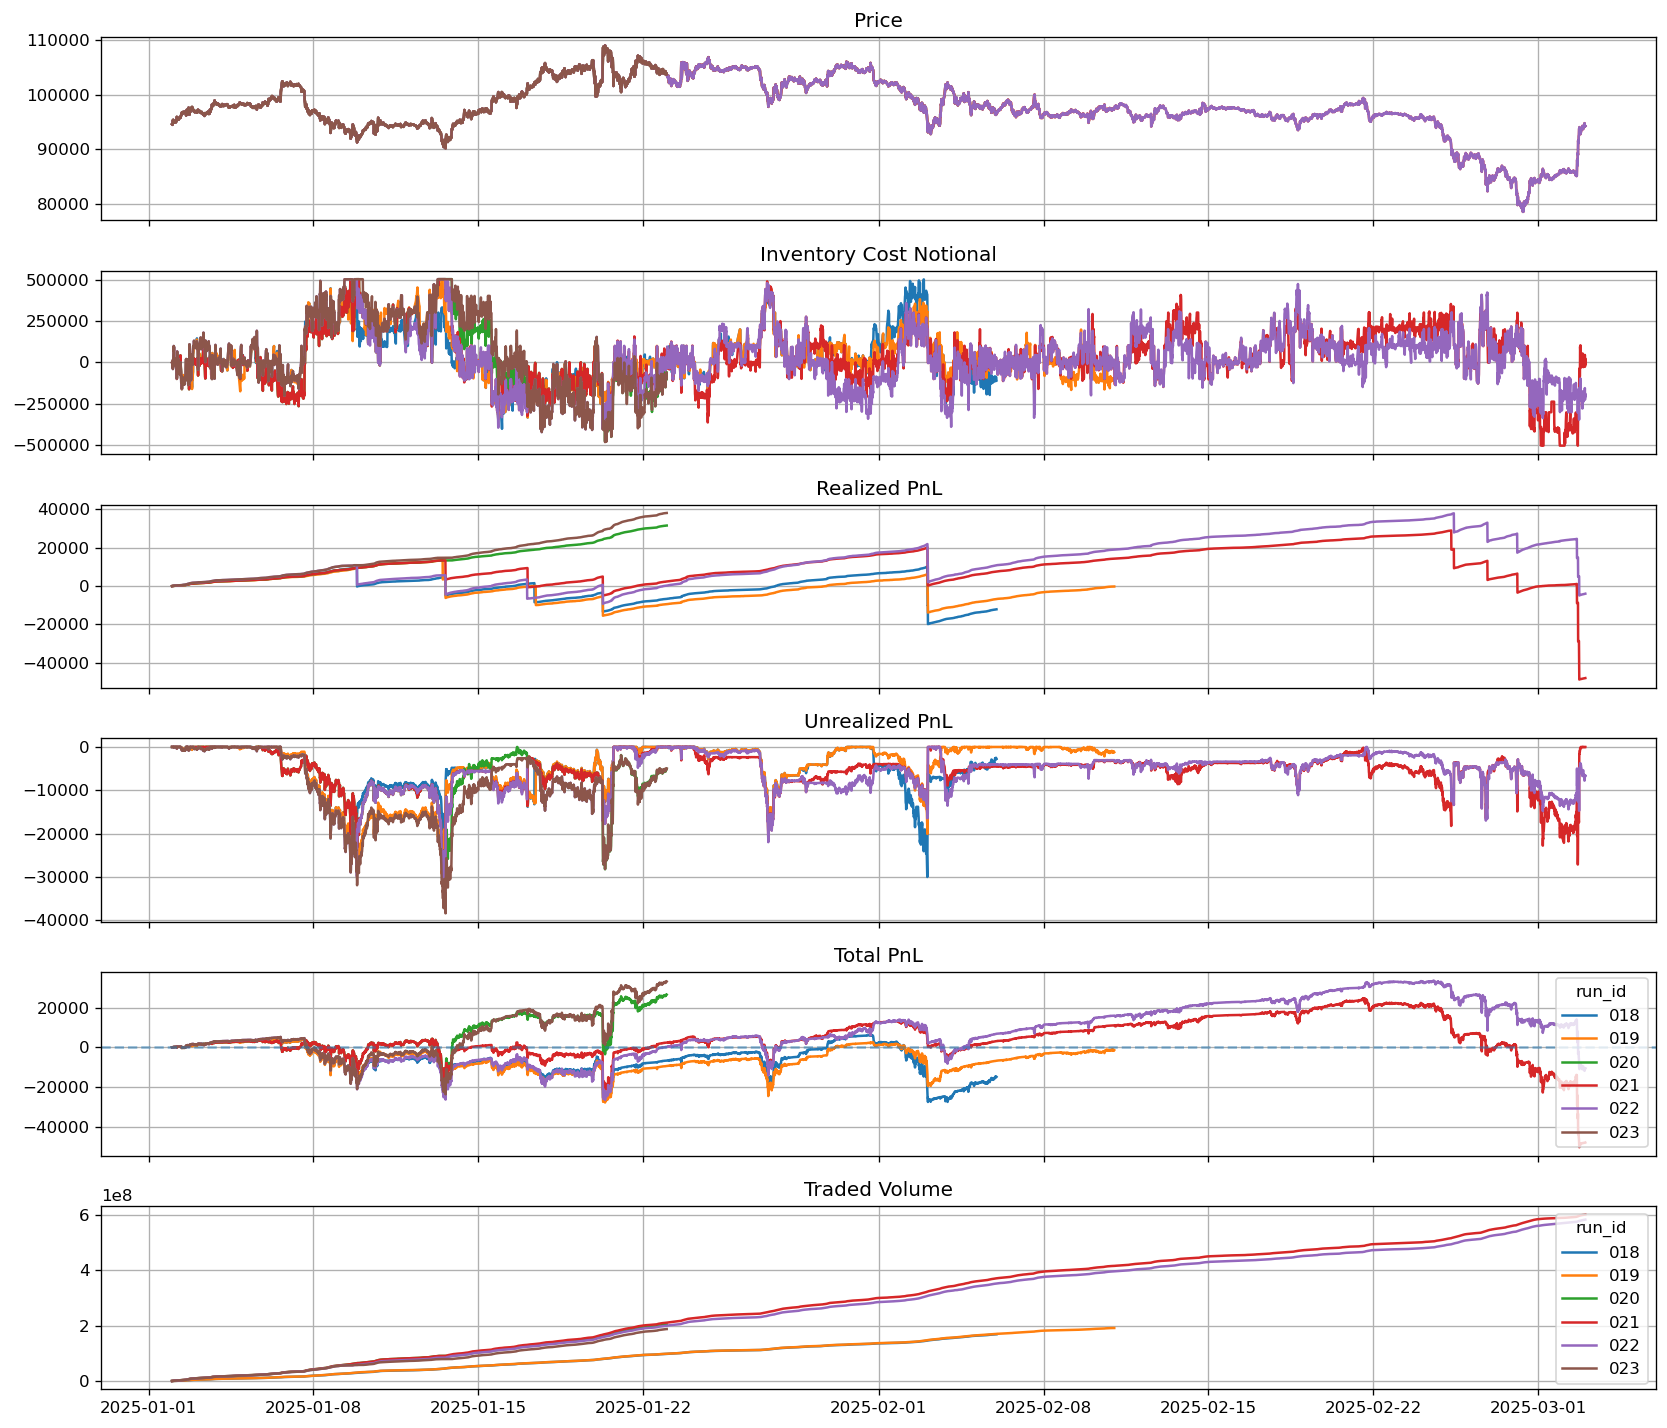

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,018,35,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,-14892.499589,-0.101704,-5.626063,31008.439972,-174455.450917,-5.626063,-0.101704,4.833792e+06,-0.000088
1,019,40,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,-1423.843044,-0.018158,-1.381362,17904.023352,-24731.938716,-1.381362,-0.018158,4.790931e+06,-0.000007
2,020,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,26551.841212,0.309196,45.181745,10129.817842,457682.843180,45.181745,0.309196,9.698963e+06,0.000130
3,021,60,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,-48007.371737,-0.150505,-4.293919,71289.053421,-306109.421404,-4.293919,-0.150505,1.003252e+07,-0.000080
4,022,60,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,-10549.031846,-0.039305,-1.707339,43721.841595,-74647.992731,-1.707339,-0.039305,9.719051e+06,-0.000018
5,023,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,33182.036820,0.294133,30.717520,18812.730244,577880.424609,30.717520,0.294133,8.904171e+06,0.000177


batch 5: run_id 024..029


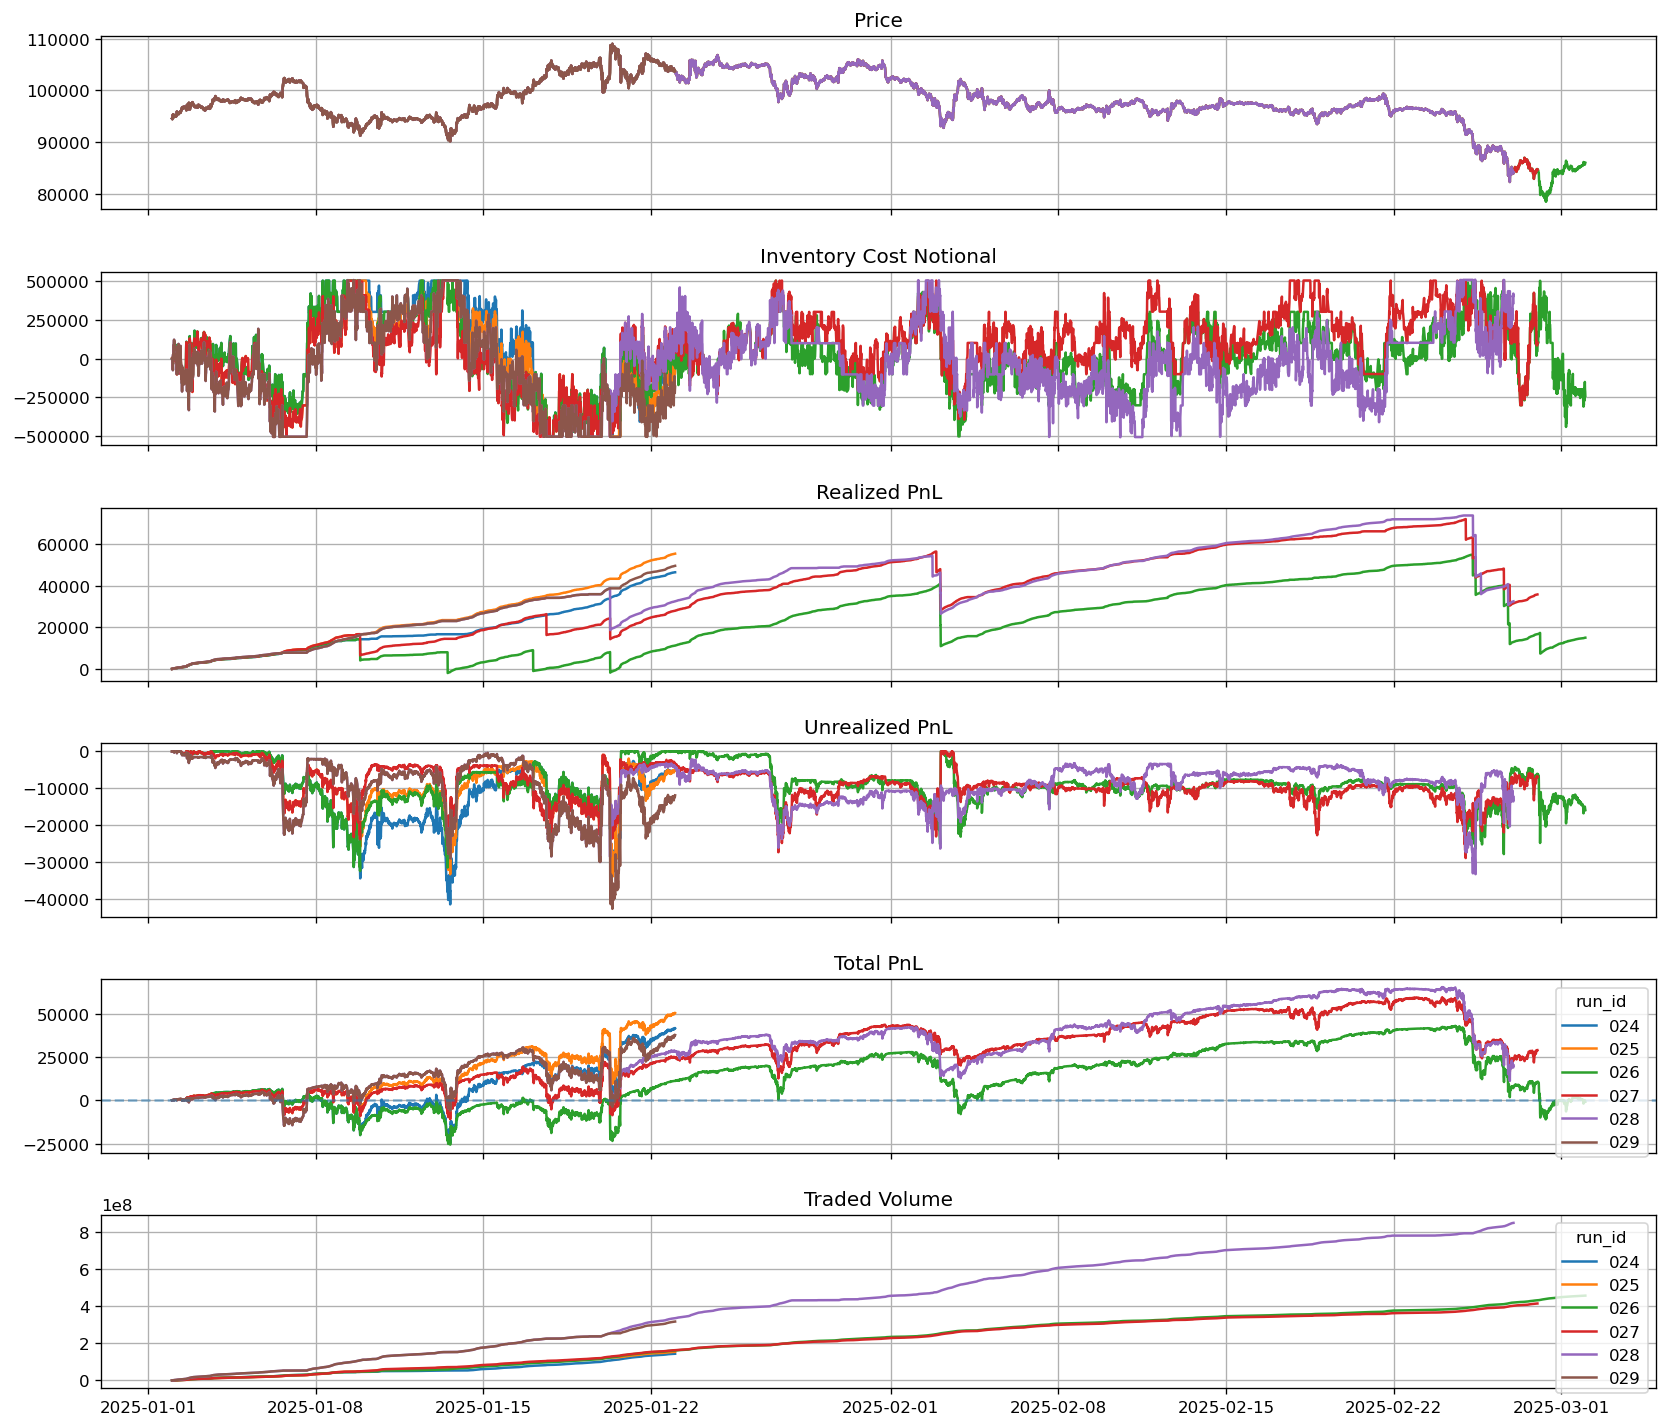

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,024,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,41565.505930,0.318773,36.343835,19666.983702,714773.605714,36.343835,0.318773,6.780925e+06,0.000288
1,025,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,50429.672284,0.343629,74.242759,11780.496454,874616.554521,74.242759,0.343629,7.314807e+06,0.000326
2,026,59,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,-844.316507,-0.008941,-0.474460,43029.473648,-20415.742678,-0.474460,-0.008941,7.748237e+06,-0.000002
3,027,57,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,28932.868917,0.077905,4.826267,35690.100634,172249.961808,4.826267,0.077905,7.271778e+06,0.000070
4,028,56,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,20174.797174,0.046519,2.790058,44918.329015,125324.729699,2.790058,0.046519,1.512280e+07,0.000024
5,029,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,37730.071122,0.207169,38.370642,17331.655925,665026.756227,38.370642,0.207169,1.494535e+07,0.000119


batch 6: run_id 030..035


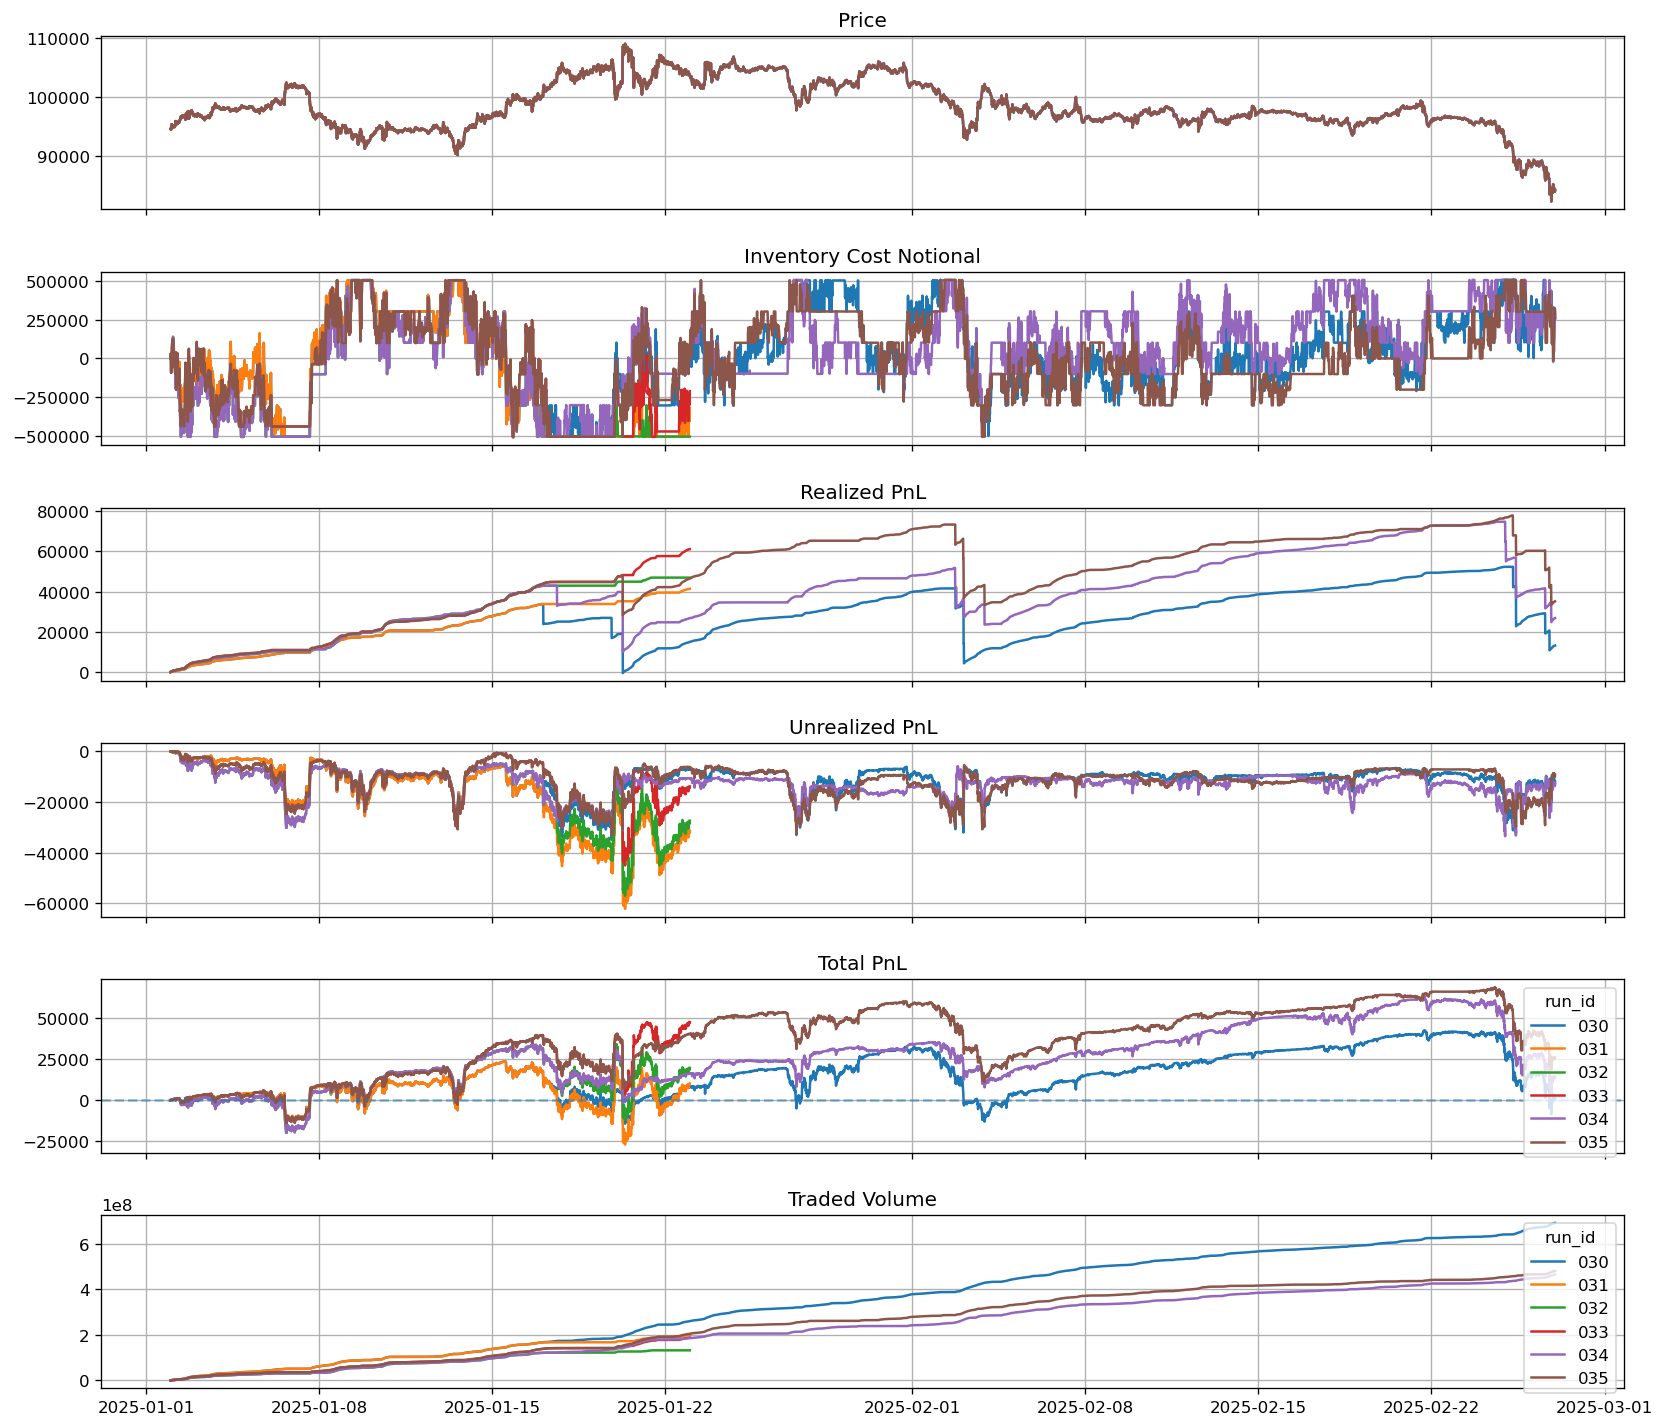

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,030,56,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,1065.549187,0.001184,0.084286,40263.445145,3393.653344,0.084286,0.001184,1.222521e+07,0.000002
1,031,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,10121.795936,0.043273,6.731909,25937.524049,174609.049873,6.731909,0.043273,9.082092e+06,0.000051
2,032,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,19619.685845,0.086757,14.491996,24791.442976,359277.483881,14.491996,0.086757,5.913869e+06,0.000149
3,033,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,47344.059239,0.225347,44.743594,18322.836198,819829.552476,44.743594,0.225347,8.612884e+06,0.000252
4,034,56,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,14071.079009,0.031274,2.012742,46614.912007,93823.785138,2.012742,0.031274,8.198723e+06,0.000030
5,035,56,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,25924.784084,0.050333,3.567772,43717.410425,155973.738505,3.567772,0.050333,8.441242e+06,0.000054


batch 7: run_id 036..041


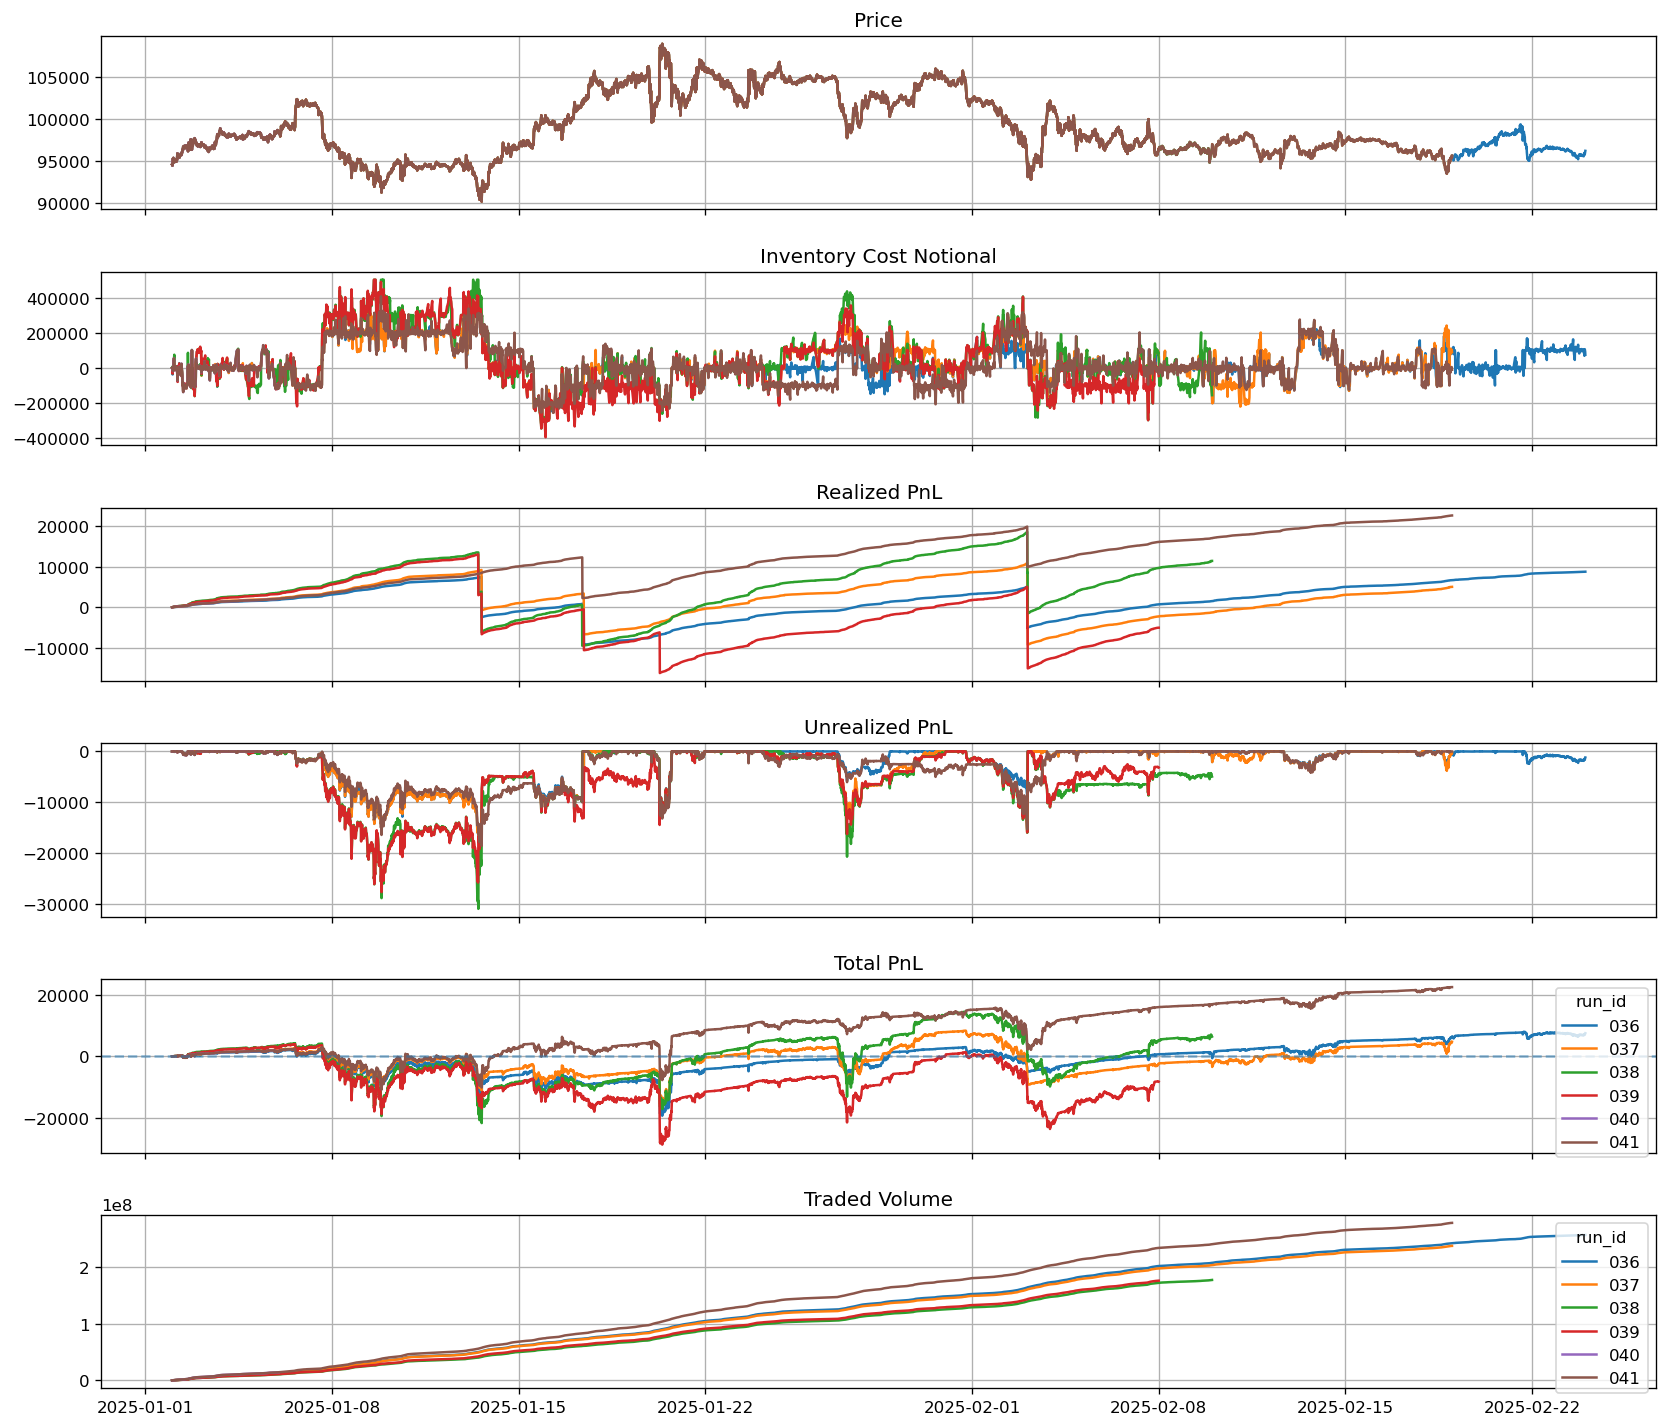

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,036,53,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,7552.168887,0.070513,4.001583,12171.053566,48703.480347,4.001583,0.070513,4.847477e+06,0.000029
1,037,48,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,4790.676186,0.034105,1.957348,16061.938858,31438.801025,1.957348,0.034105,4.954290e+06,0.000020
2,038,39,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,6455.851675,0.029748,2.215060,21369.736514,47335.249232,2.215060,0.029748,4.556998e+06,0.000036
3,039,37,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,-8176.233403,-0.055698,-3.835378,24615.845405,-94411.062566,-3.835378,-0.055698,4.776296e+06,-0.000046
4,040,4,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,1774.539768,1.100985,NaN,0.000000,112617.329540,NaN,1.100985,2.873232e+06,0.000123
5,041,48,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,22564.468010,0.245827,19.843497,8498.604982,168642.038236,19.843497,0.245827,5.801743e+06,0.000081


batch 8: run_id 042..047


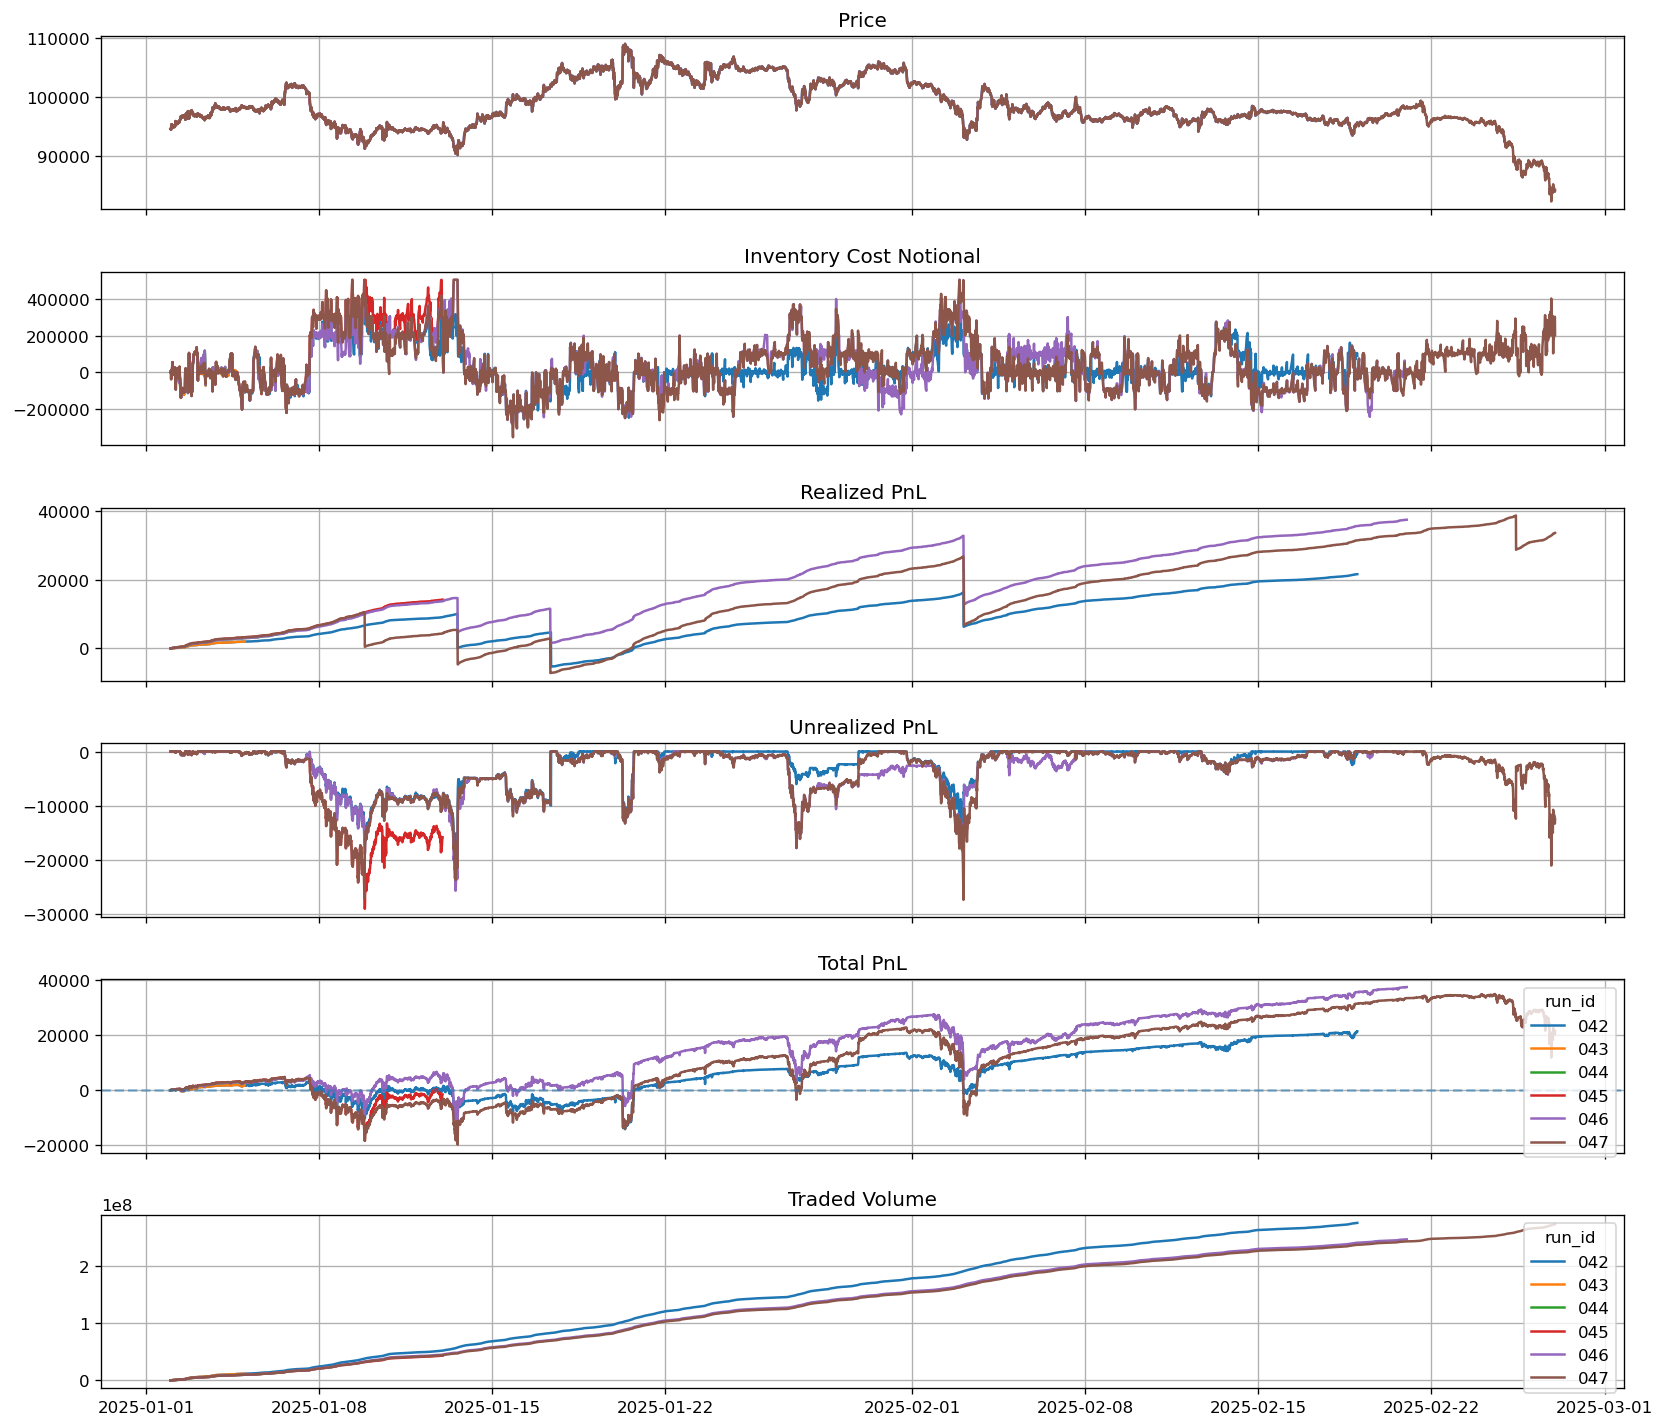

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,042,48,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,21381.425565,0.199013,16.358315,9763.866107,159720.402209,16.358315,0.199013,5.720642e+06,0.000078
1,043,3,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,1767.118098,0.831124,NaN,0.000000,173818.339171,NaN,0.831124,3.097234e+06,0.000149
2,044,5,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,2951.377889,0.592529,362.702294,404.832412,146833.644673,362.702294,0.592529,2.986784e+06,0.000177
3,045,11,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-1574.354888,-0.069969,-7.168555,15537.723758,-111383.031544,-7.168555,-0.069969,3.835966e+06,-0.000036
4,046,50,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,37523.147726,0.274232,22.842873,11798.464755,269510.827944,22.842873,0.274232,4.919822e+06,0.000153
5,047,56,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,21212.651053,0.113569,7.864459,16653.579863,130971.397331,7.864459,0.113569,4.860979e+06,0.000078


batch 9: run_id 048..053


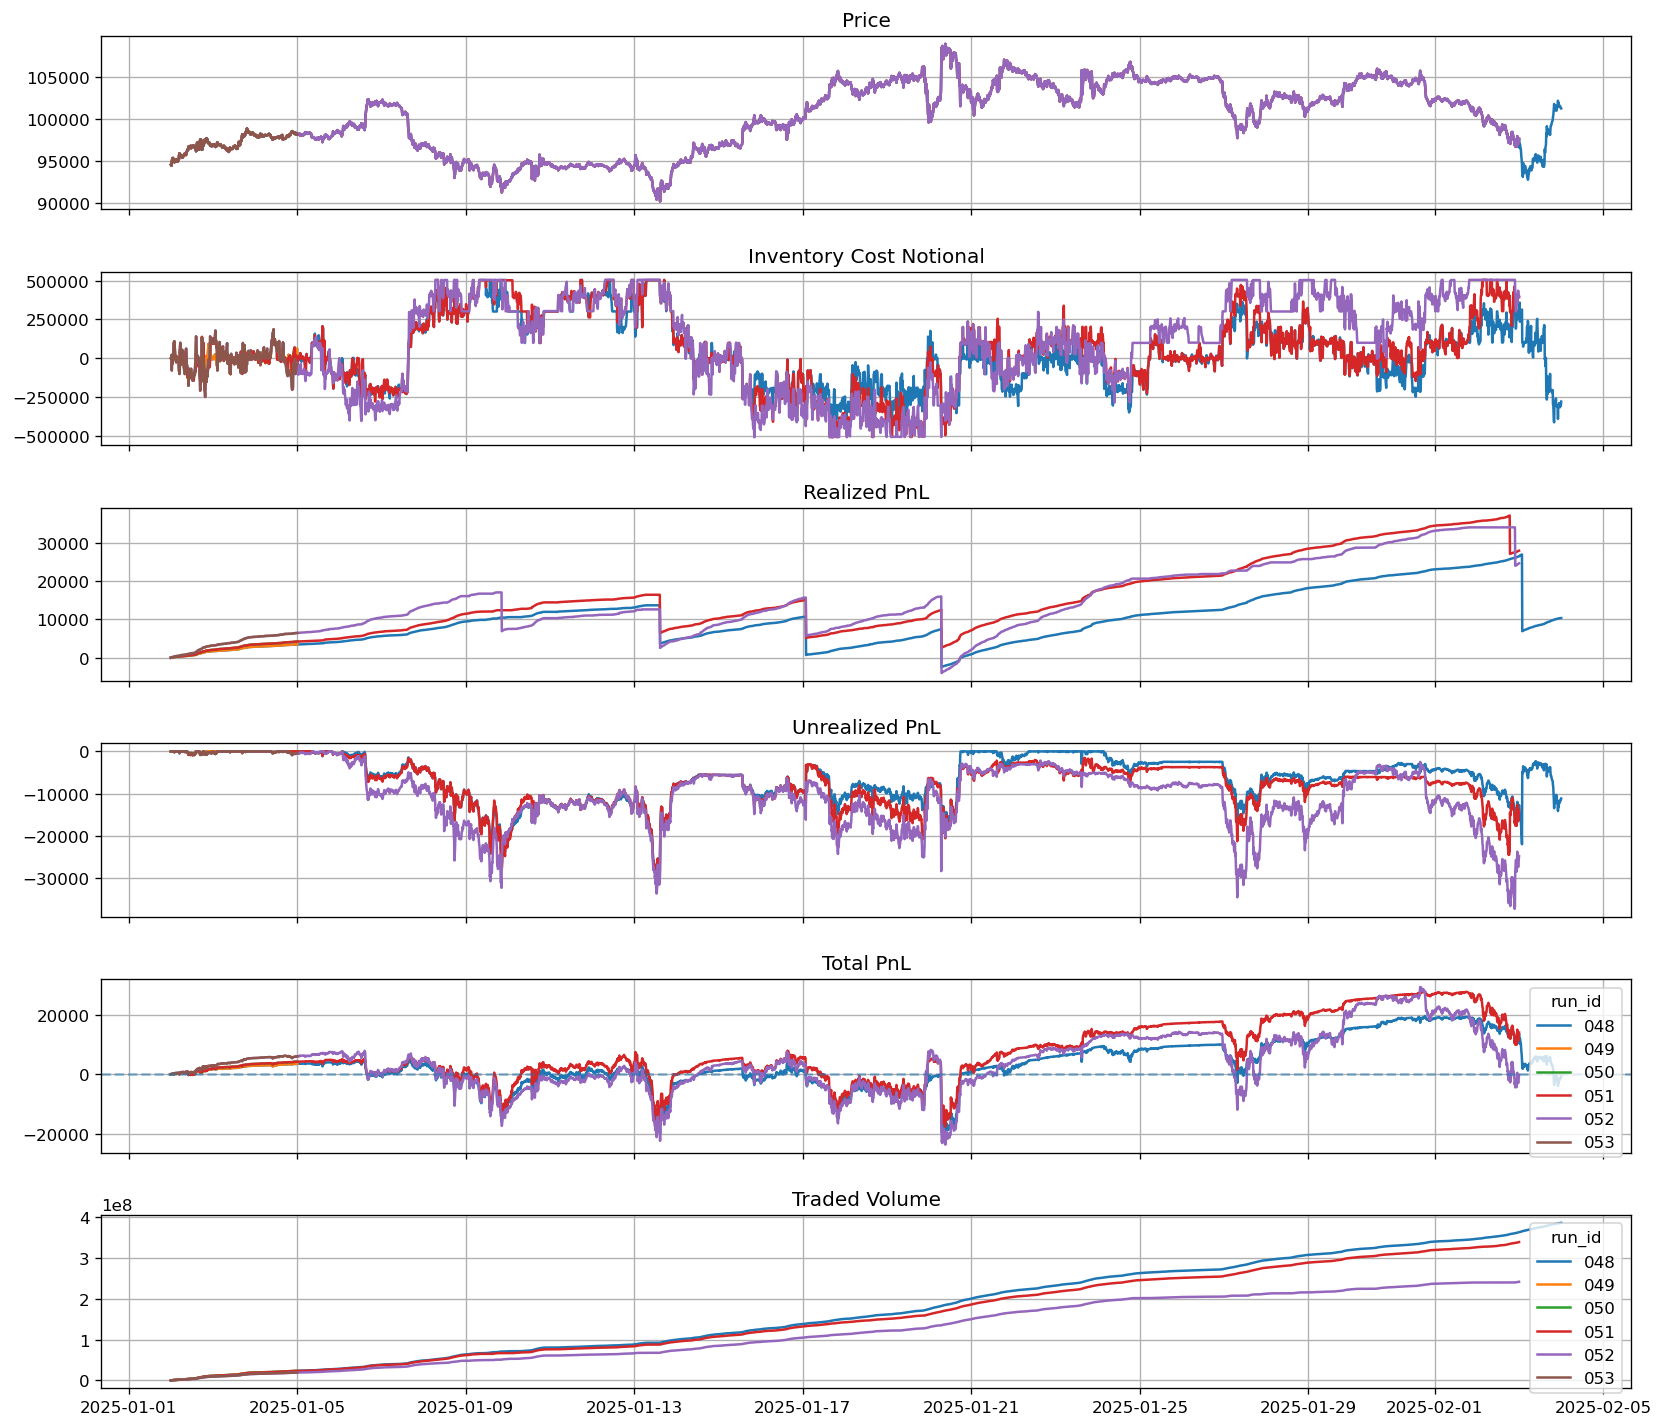

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,048,33,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-840.540881,-0.016768,-1.486450,19599.929208,-29134.314157,-1.486450,-0.016768,1.167958e+07,-0.000002
1,049,3,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,3481.805166,2.282805,NaN,0.000000,322679.127000,NaN,2.282805,6.160585e+06,0.000147
2,050,3,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,4210.771766,2.059006,NaN,0.000000,412856.428321,NaN,2.059006,6.057193e+06,0.000182
3,051,32,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,14006.867543,0.073221,10.625863,13361.457924,141977.026298,10.625863,0.073221,1.055605e+07,0.000041
4,052,32,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-261.607732,-0.014728,-1.477794,25425.607544,-37573.811903,-1.477794,-0.014728,7.478890e+06,-0.000001
5,053,3,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,6038.744725,1.136058,NaN,0.000000,567420.238834,NaN,1.136058,4.976464e+06,0.000312


batch 10: run_id 054..059


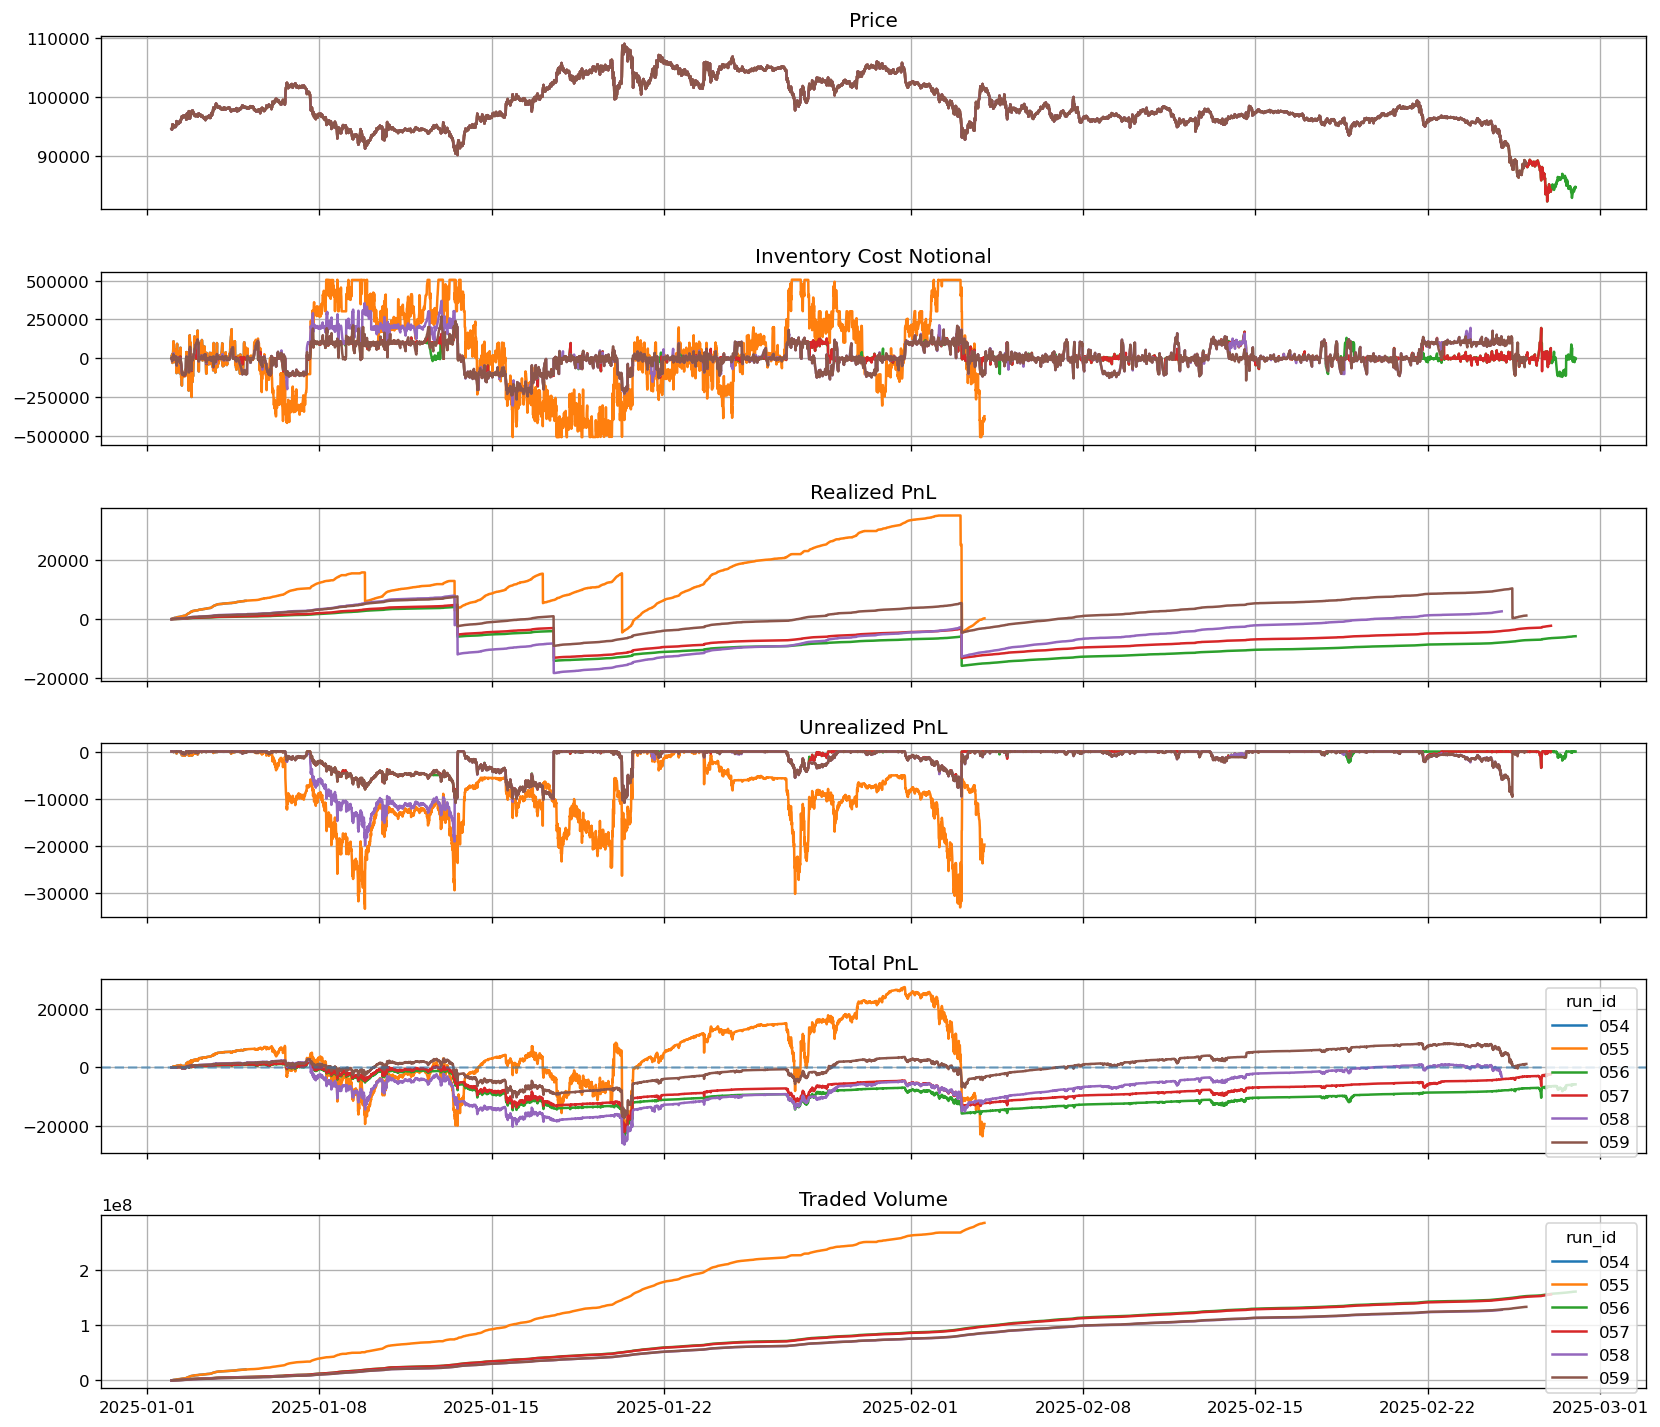

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,054,3,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,6172.191875,1.740989,NaN,0.000000,631032.907625,NaN,1.740989,5.203653e+06,0.000310
1,055,33,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-19395.889114,-0.089241,-5.636913,44740.154436,-252196.367056,-5.636913,-0.089241,8.617222e+06,-0.000068
2,056,57,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-5790.173808,-0.070134,-2.551335,15896.164409,-40556.441620,-2.551335,-0.070134,2.819259e+06,-0.000036
3,057,56,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-2247.108879,-0.031227,-1.236396,14721.692904,-18201.842014,-1.236396,-0.031227,2.774955e+06,-0.000014
4,058,54,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-3225.541252,-0.032413,-1.276771,21420.112412,-27348.586294,-1.276771,-0.032413,2.365172e+06,-0.000025
5,059,55,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,1213.907509,0.005360,0.282783,12285.213773,3474.045841,0.282783,0.005360,2.421214e+06,0.000009


batch 11: run_id 060..065


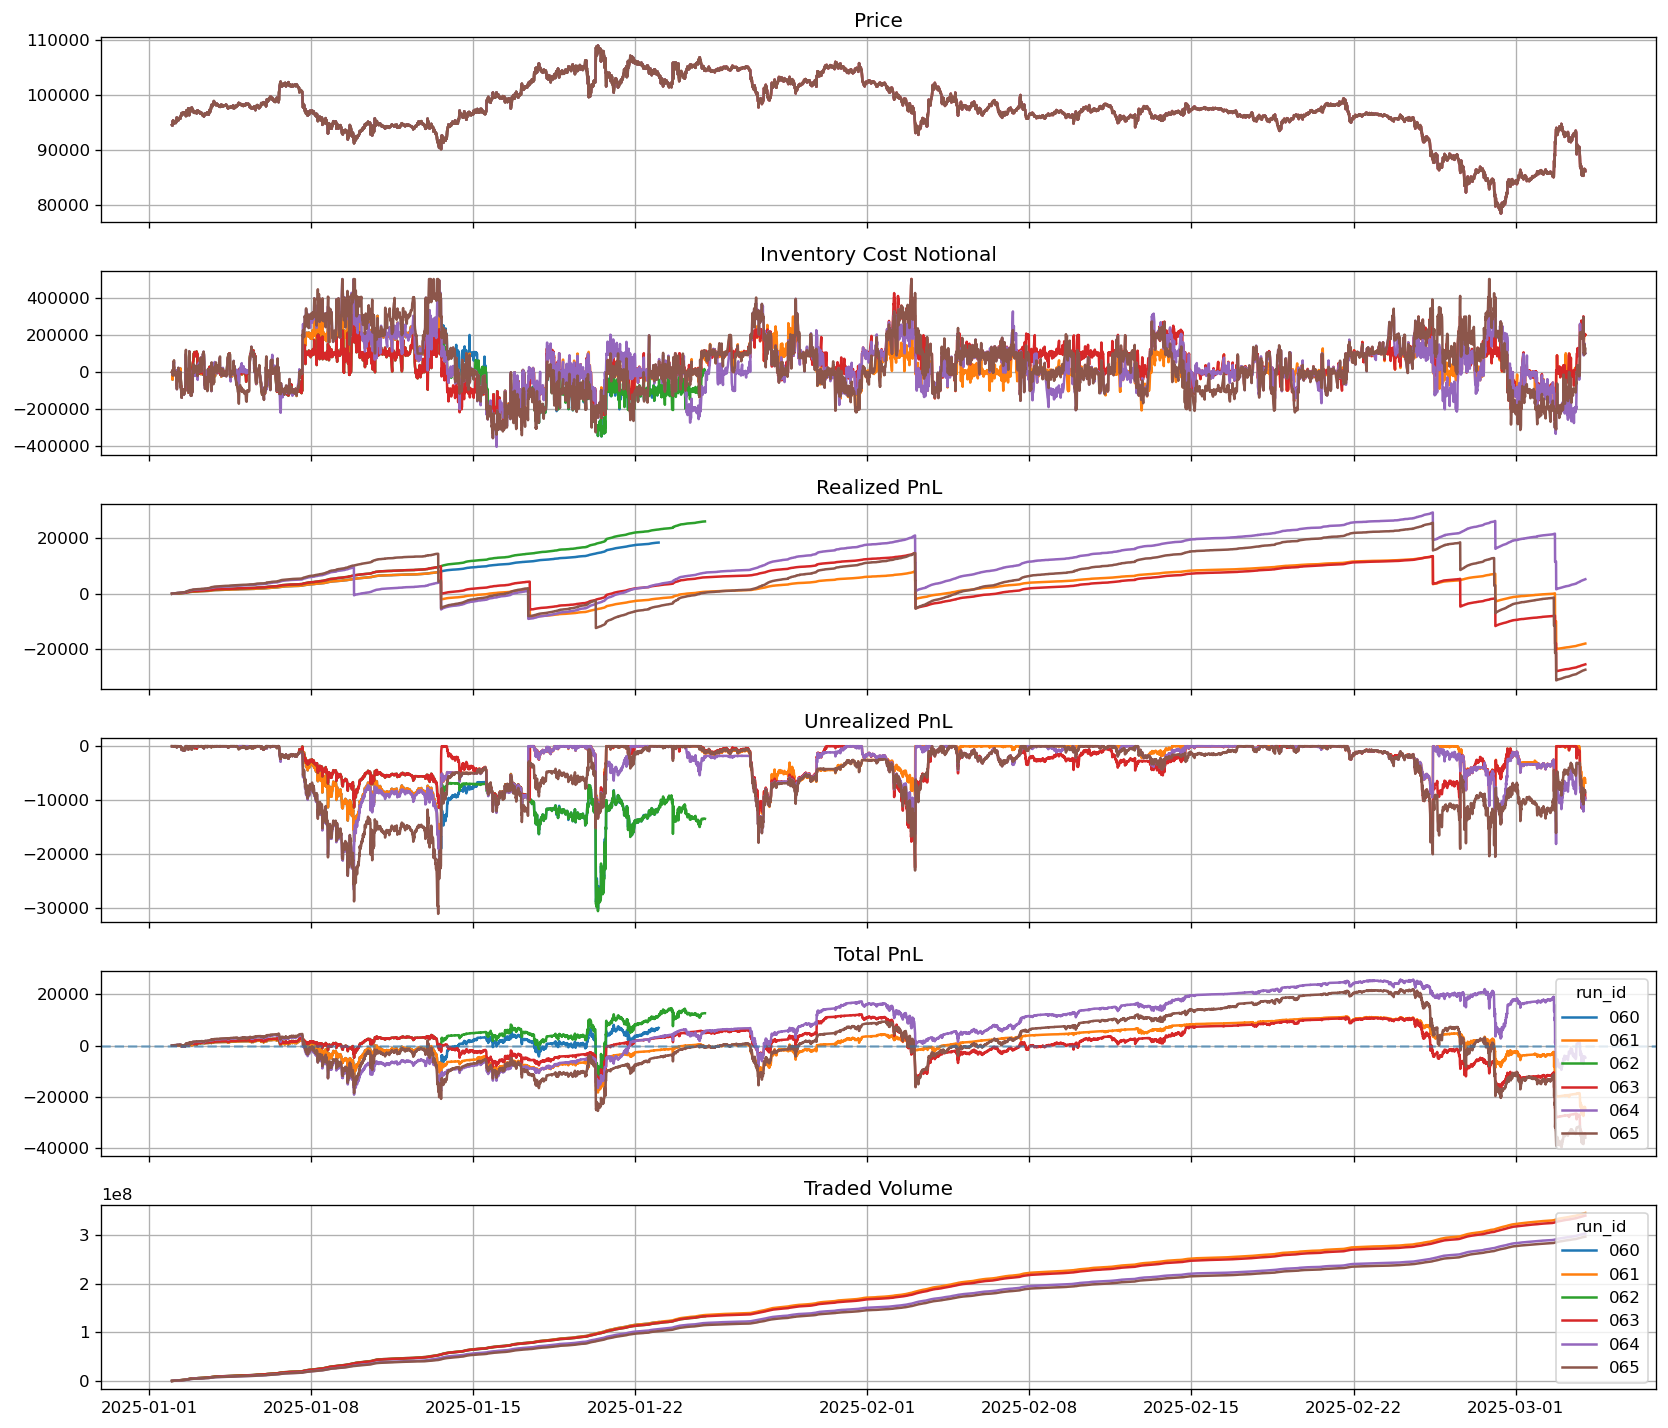

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,060,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,6907.330090,0.107234,12.532167,9127.435885,114386.547510,12.532167,0.107234,5.799358e+06,0.000057
1,061,61,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-24710.365849,-0.138497,-4.323020,35672.316750,-154212.134461,-4.323020,-0.138497,5.681478e+06,-0.000071
2,062,23,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,12631.256459,0.230584,47.853434,4095.171167,195968.003504,47.853434,0.230584,5.814767e+06,0.000095
3,063,61,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-34971.038324,-0.170040,-4.678235,46540.133787,-217725.691978,-4.678235,-0.170040,5.594280e+06,-0.000103
4,064,61,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-4660.452241,-0.022567,-1.108481,33598.882705,-37243.723042,-1.108481,-0.022567,4.987191e+06,-0.000015
5,065,61,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-35893.930000,-0.124317,-3.794704,60086.247270,-228009.540631,-3.794704,-0.124317,4.880195e+06,-0.000121


batch 12: run_id 066..071


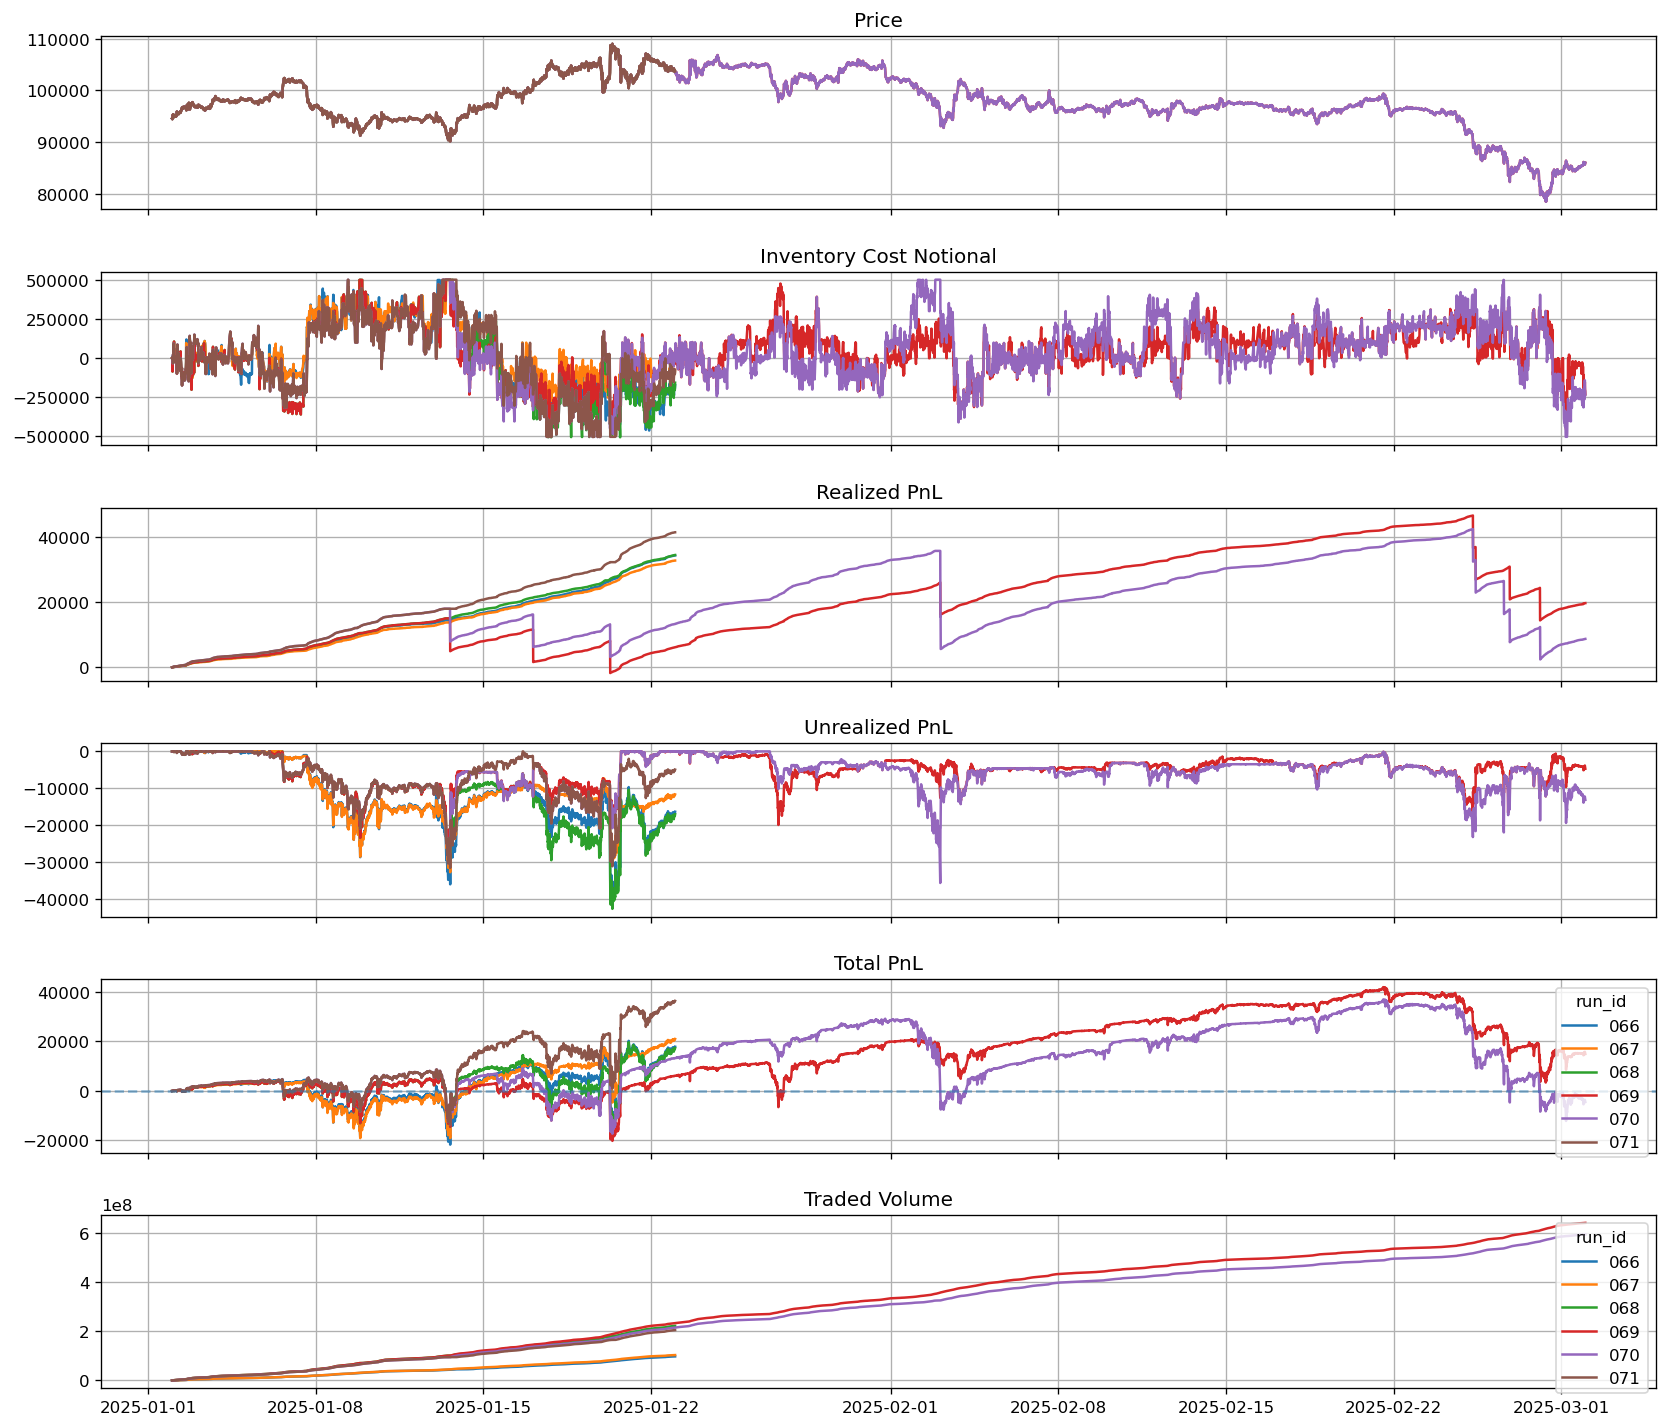

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,066,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,17891.481738,0.164346,19.138516,15547.450836,297555.142334,19.138516,0.164346,4.660136e+06,0.000183
1,067,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,21013.243812,0.248550,22.120223,16130.659388,356813.783853,22.120223,0.248550,4.933504e+06,0.000203
2,068,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,17351.357129,0.140820,24.873807,11550.946730,287316.025097,24.873807,0.140820,1.057686e+07,0.000078
3,069,59,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,14956.580871,0.057633,3.293277,25507.700214,84003.916686,3.293277,0.057633,1.087967e+07,0.000023
4,070,59,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-4443.334267,-0.020276,-0.966566,39829.463550,-38497.823707,-0.966566,-0.020276,1.007948e+07,-0.000007
5,071,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,36406.781836,0.354211,68.446544,9260.817224,633870.930137,68.446544,0.354211,9.737958e+06,0.000178


batch 13: run_id 072..077


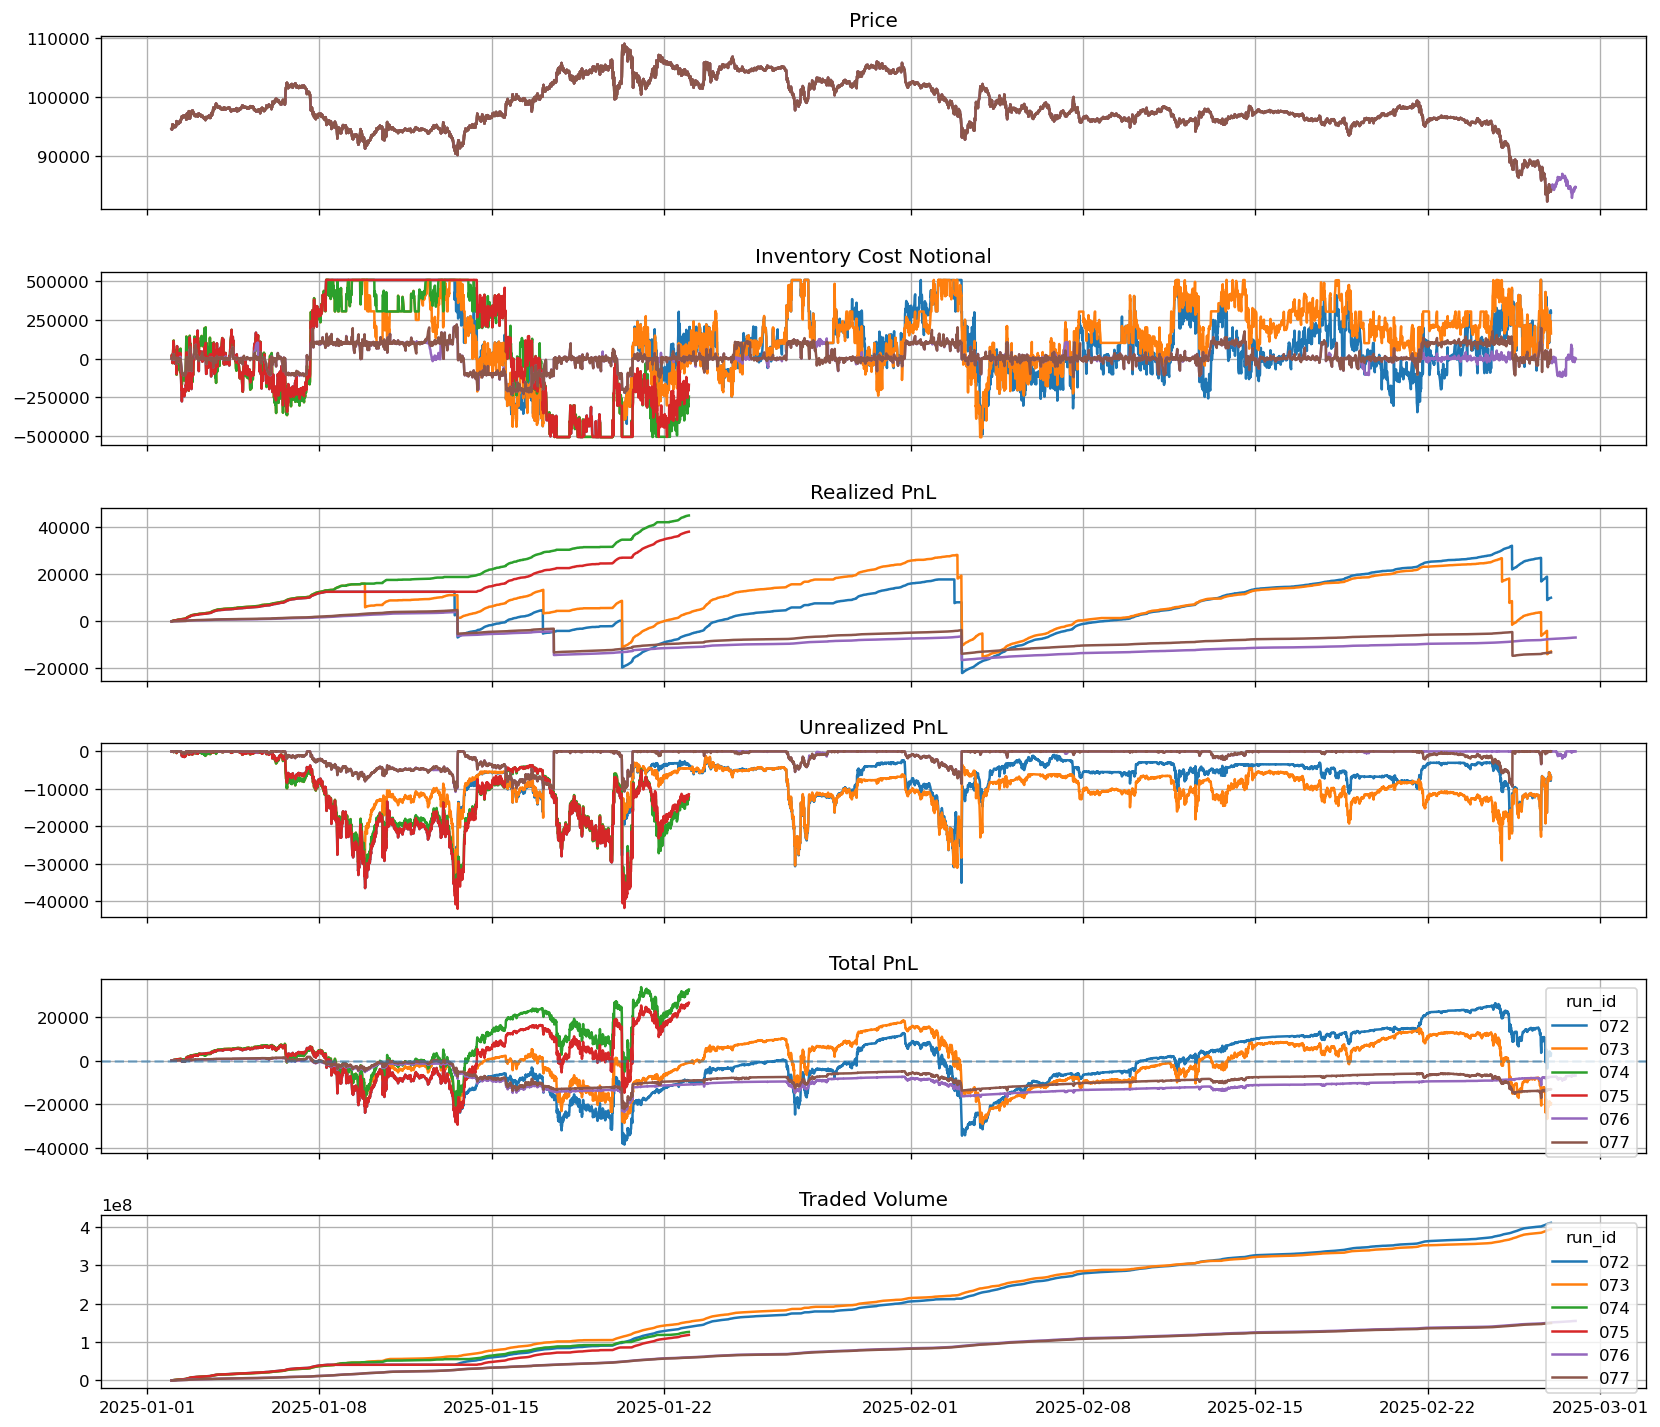

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,072,56,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,3081.910411,0.001576,0.099418,37626.543519,3740.769333,0.099418,0.001576,7.303487e+06,0.000008
1,073,56,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-19761.430759,-0.058607,-3.534863,42194.002276,-149150.011922,-3.534863,-0.058607,7.007068e+06,-0.000050
2,074,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,32697.598909,0.195312,29.627872,18469.593903,547214.758672,29.627872,0.195312,5.885223e+06,0.000258
3,075,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,26638.016241,0.158693,18.477213,23823.184736,440186.047075,18.477213,0.158693,5.481718e+06,0.000224
4,076,57,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-6898.172956,-0.082370,-2.878089,16568.495692,-47685.598609,-2.878089,-0.082370,2.719148e+06,-0.000044
5,077,56,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-13236.719950,-0.143051,-6.015218,15136.079620,-91046.823137,-6.015218,-0.143051,2.668529e+06,-0.000088


batch 14: run_id 078..079


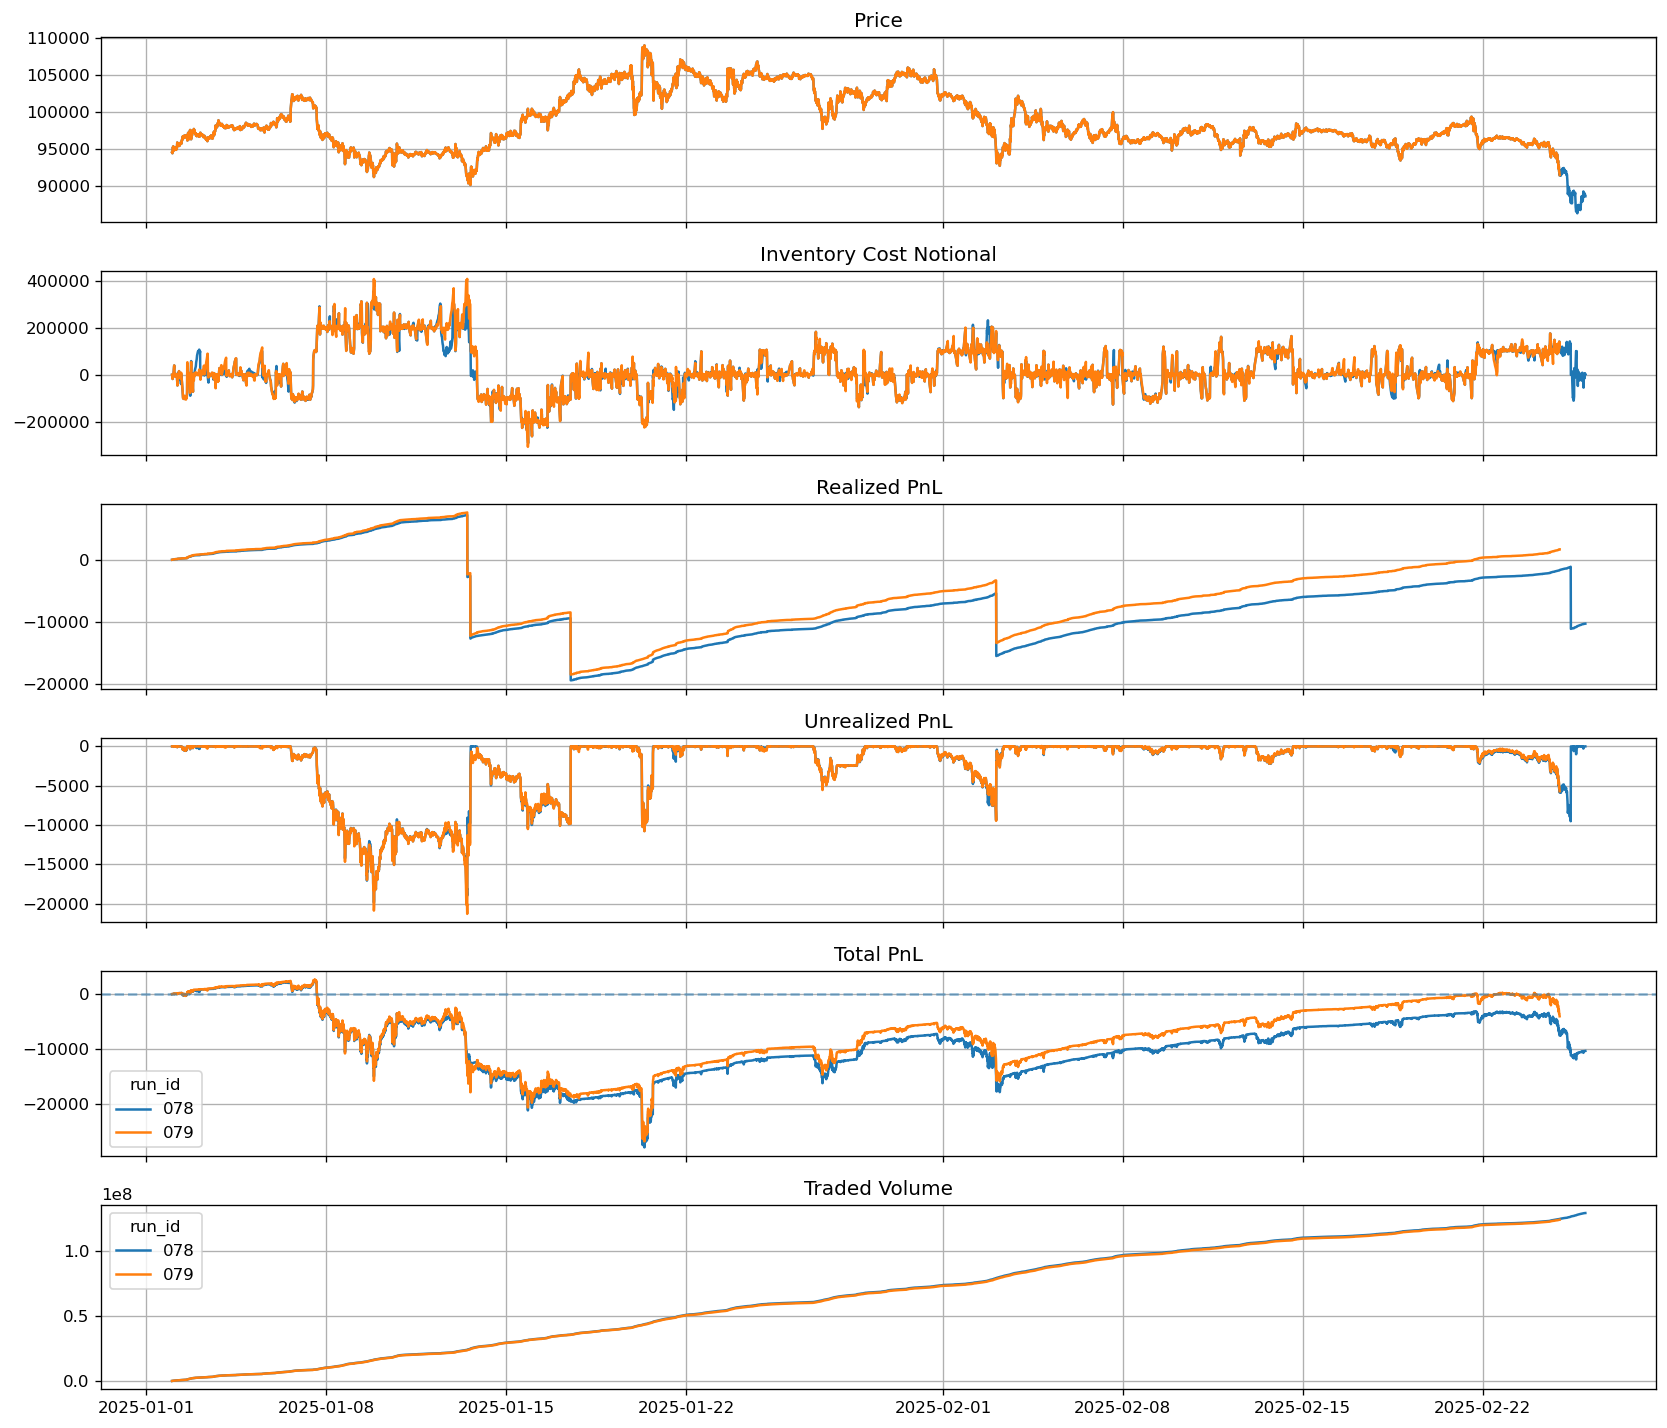

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,078,55,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-10317.999637,-0.086699,-3.333183,22323.545355,-74408.457715,-3.333183,-0.086699,2.342668e+06,-0.000080
1,079,54,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,-4024.753517,-0.039667,-1.548165,21585.972679,-33418.645876,-1.548165,-0.039667,2.289109e+06,-0.000033


,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,025,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,50429.672284,0.343629,74.242759,11780.496454,874616.554521,74.242759,0.343629,7.314807e+06,0.000326
1,010,57,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,47403.081775,0.096083,6.973369,43897.580909,306114.042168,6.973369,0.096083,1.438565e+07,0.000057
2,033,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,47344.059239,0.225347,44.743594,18322.836198,819829.552476,44.743594,0.225347,8.612884e+06,0.000252
3,005,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,47268.695137,0.348477,67.172193,12183.993221,818425.541948,67.172193,0.348477,7.986552e+06,0.000280
4,024,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,41565.505930,0.318773,36.343835,19666.983702,714773.605714,36.343835,0.318773,6.780925e+06,0.000288
5,006,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,39655.883075,0.310523,36.759292,18374.569438,675436.169763,36.759292,0.310523,6.648930e+06,0.000280
6,029,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,37730.071122,0.207169,38.370642,17331.655925,665026.756227,38.370642,0.207169,1.494535e+07,0.000119
7,046,50,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,37523.147726,0.274232,22.842873,11798.464755,269510.827944,22.842873,0.274232,4.919822e+06,0.000153
8,071,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,36406.781836,0.354211,68.446544,9260.817224,633870.930137,68.446544,0.354211,9.737958e+06,0.000178
9,002,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,36376.895770,0.333615,66.508434,9548.988986,635088.299813,66.508434,0.333615,9.894600e+06,0.000175


In [5]:
plot_df = choose_folders(limit=MAX_FOLDERS)
all_metrics = []

for start in range(0, len(plot_df), BATCH_SIZE):
    batch = plot_df.iloc[start : start + BATCH_SIZE]
    first_id = int(batch["run_id"].iloc[0])
    last_id = int(batch["run_id"].iloc[-1])
    print(f"batch {start // BATCH_SIZE + 1}: run_id {first_id:03d}..{last_id:03d}")
    all_metrics.append(plot_folder_batch(batch))

summary_df = pd.concat(all_metrics, ignore_index=True) if all_metrics else pd.DataFrame()
display(summary_df.sort_values("pnls", ascending=False).reset_index(drop=True))

Inspect one folder with the full report panels.

run_id=042
/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__mon100__moq0__md0__irbbo_imbalance__ink__vnsigma__ocu0x1x0__opo1__oa1000__pp1__pg2x52x10xexponentialx0__h823df332ca/strat__all


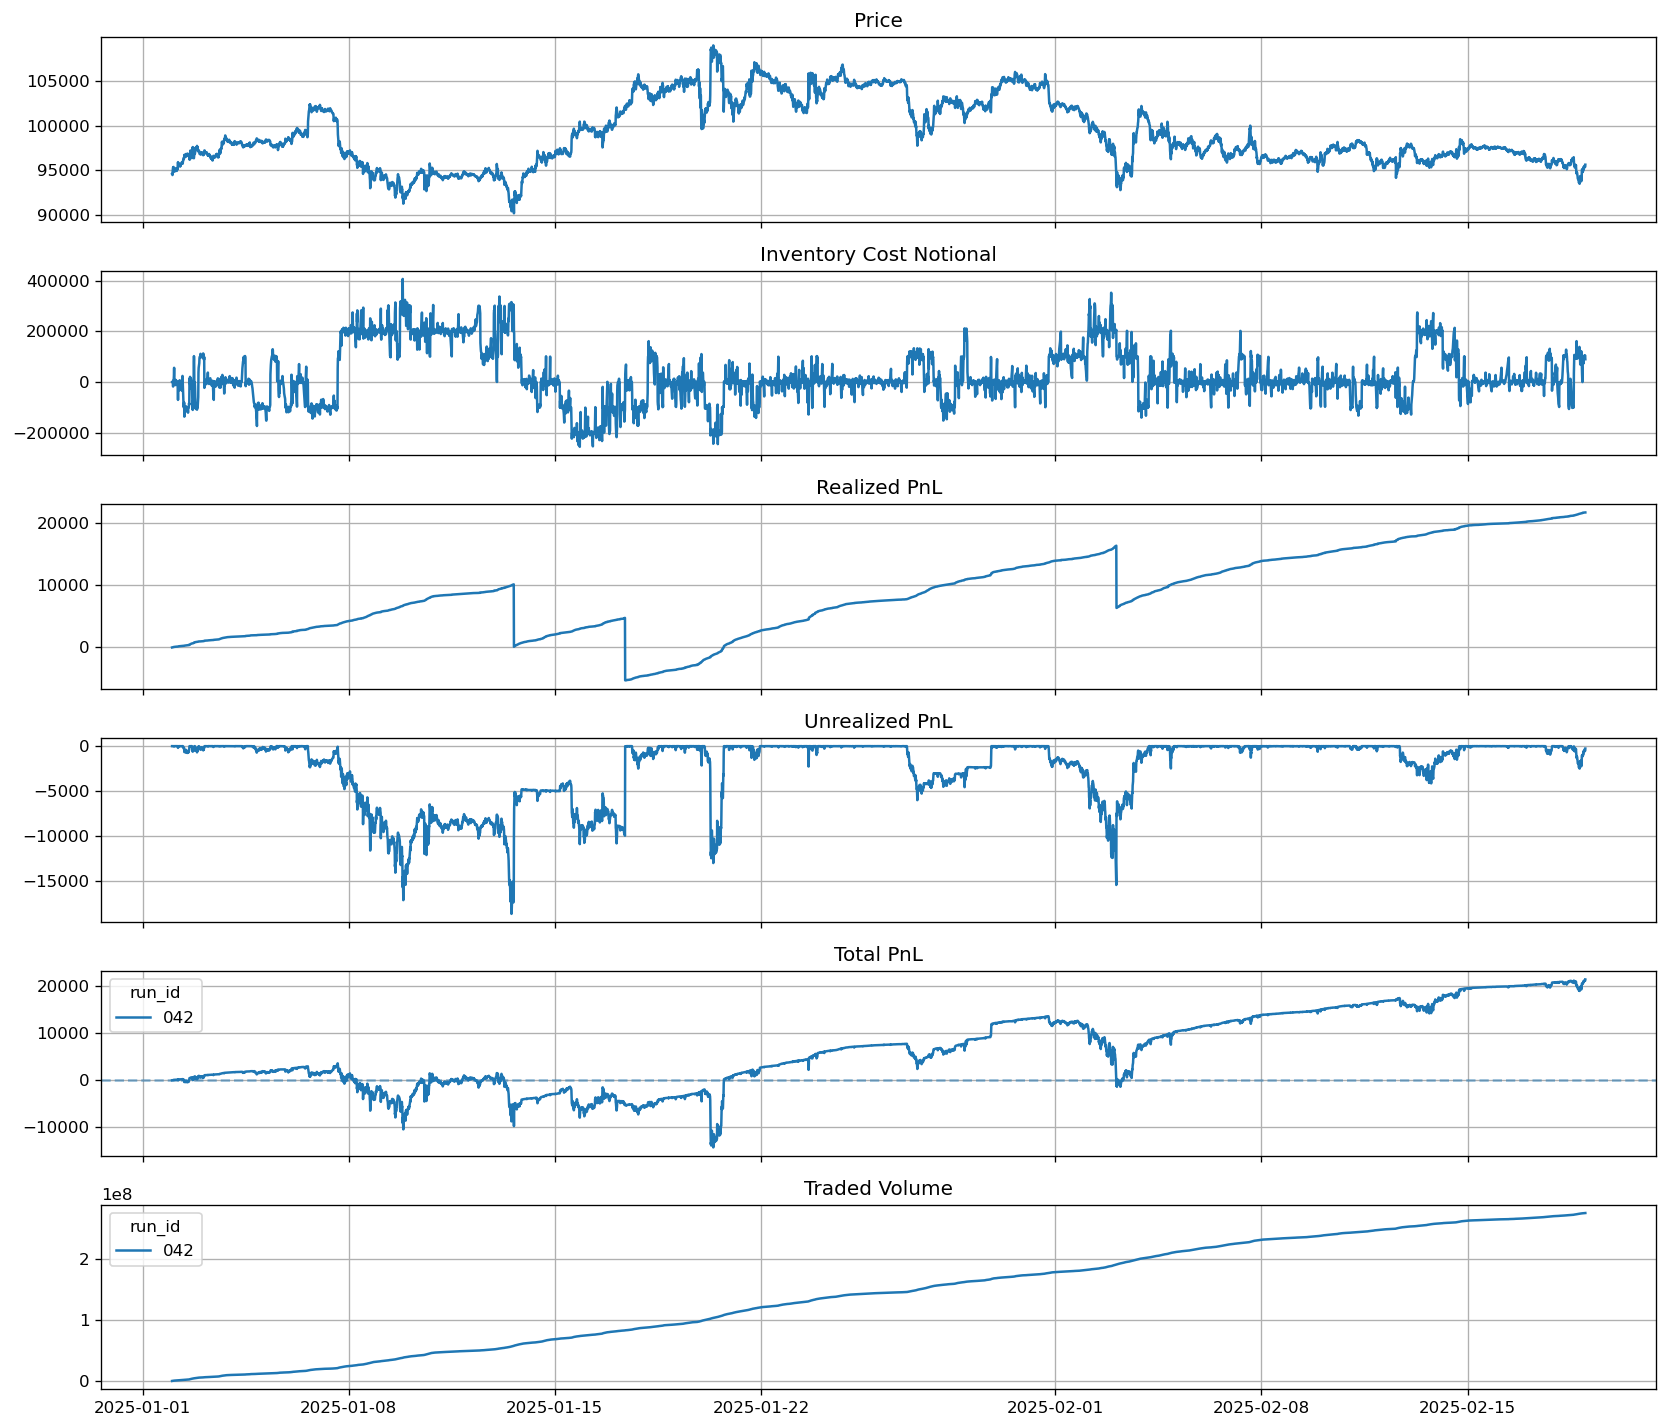

{'pnls': array([21381.42556463]),
 'sharpes': array([0.19901265]),
 'calmars': array([16.35831549]),
 'max_drawdown': array([9763.8661071]),
 'annual_return': array([159720.40220905]),
 'calmar': array([16.35831549]),
 'sharpe': array([0.19901265]),
 'daily_turnover': array([5720642.37444687]),
 'spnl': array([7.78861572e-05])}

In [6]:
FOLDER_ID = int(folder_df["run_id"].iloc[42])
one = folder_df.loc[folder_df["run_id"] == FOLDER_ID].iloc[0]

print(f"run_id={FOLDER_ID:03d}")
print(one["folder"])

report_tools.report(
    one["folder"],
    every=EVERY,
    pnl_only=False,
    srt=SRT,
    end=END,
    exclude_date=EXCLUDE_DATE,
    labels=[f"{FOLDER_ID:03d}"],
    normalize=NORMALIZE,
)

Compare selected folders on one PnL chart.

,run_id,run_name,file_count,folder
0,20,sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__mon100__moq0__md1__irbbo_imbalance__ink__vnsigma__ocu...,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...


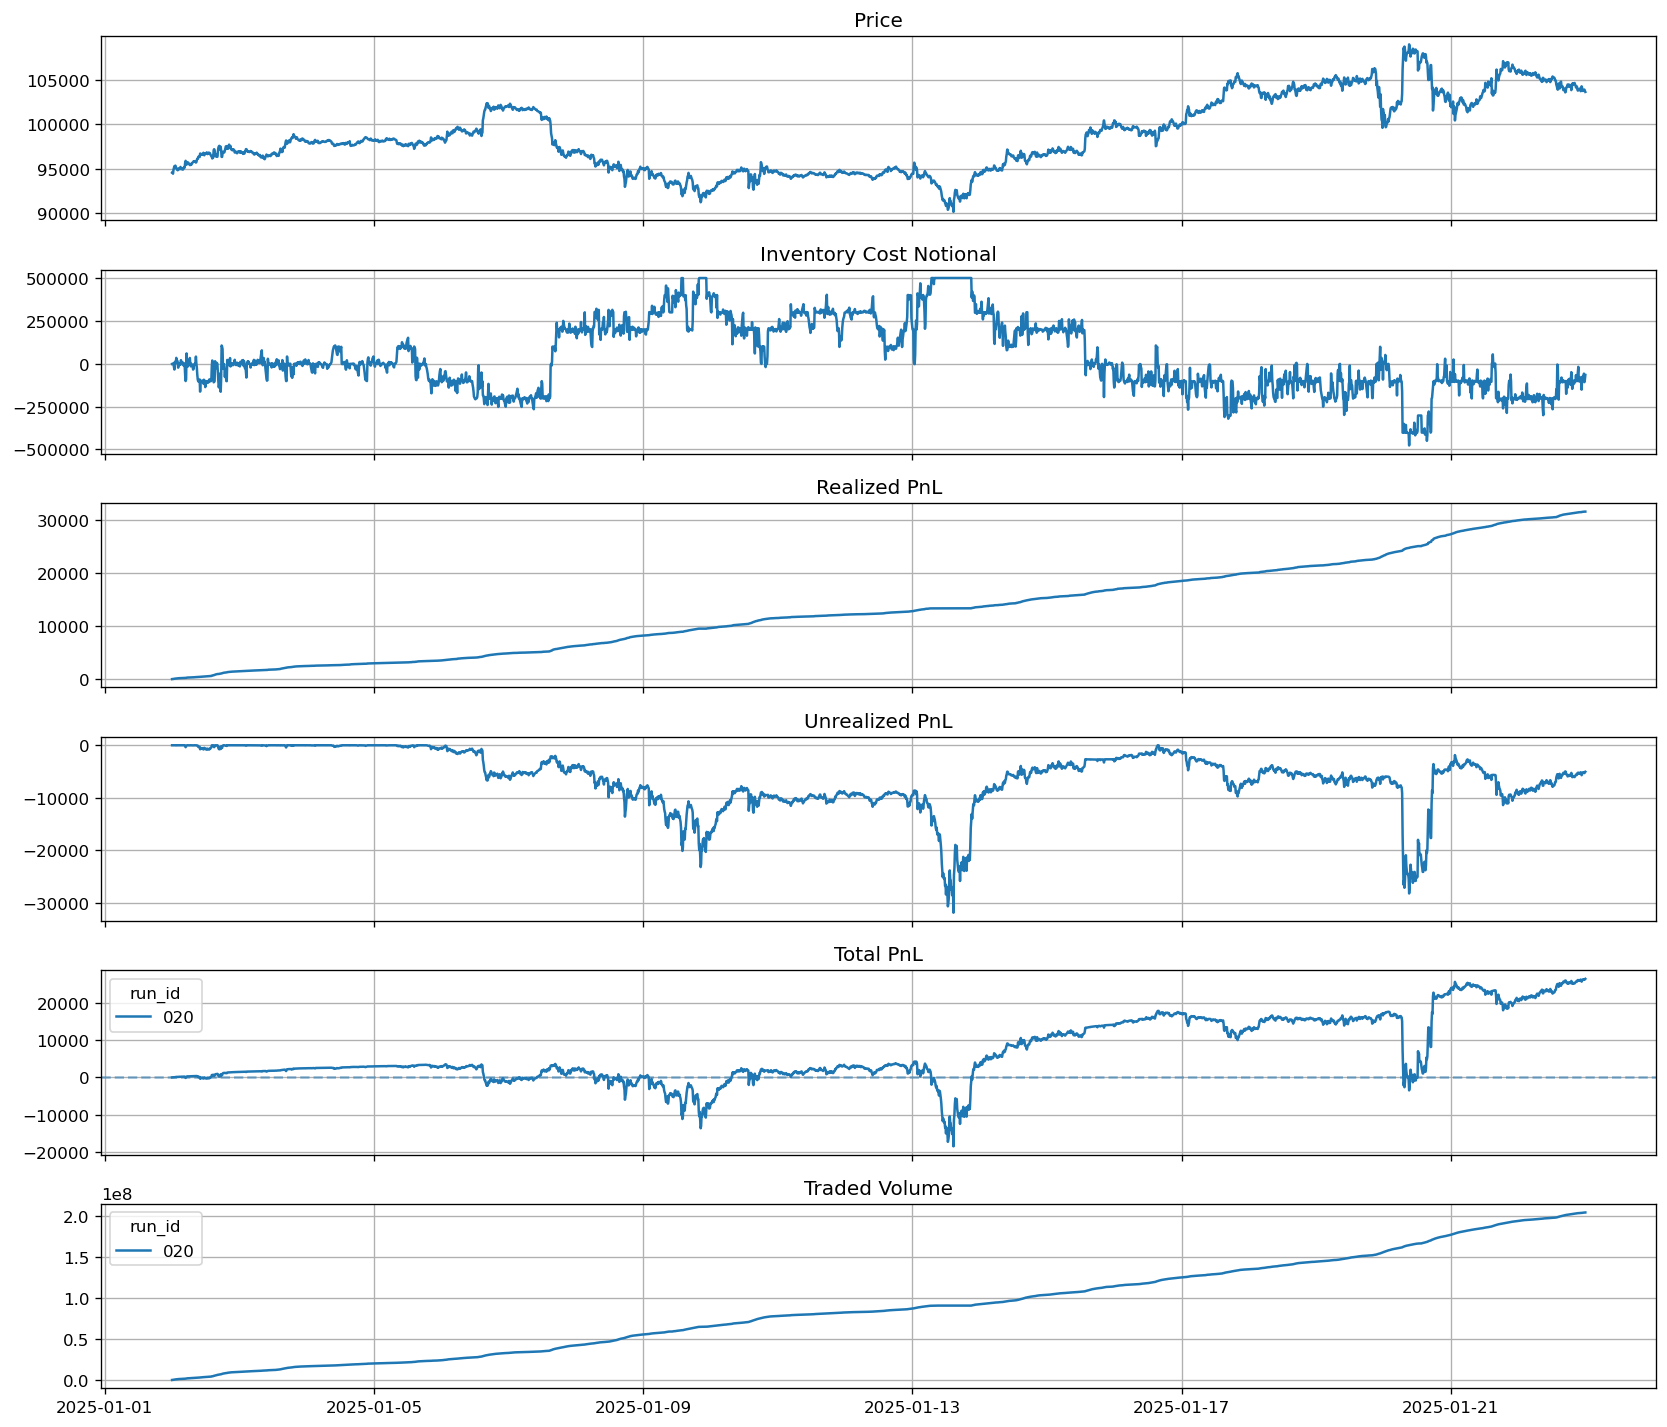

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,020,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,26551.841212,0.309196,45.181745,10129.817842,457682.84318,45.181745,0.309196,9.698963e+06,0.00013


,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,020,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,26551.841212,0.309196,45.181745,10129.817842,457682.84318,45.181745,0.309196,9.698963e+06,0.00013


In [7]:
SELECTED_IDS = [20]
selected = choose_folders(indices=SELECTED_IDS)
display(selected)

plot_folder_batch(selected, pnl_only=False)

In [8]:
summary_df.sort_values("pnls", ascending=False).iloc[0].folder

'/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__mon100__moq0__md1__irbbo_imbalance__ink__vnsigma__ocu0x1x0__opo1__oa1000__pp1__pg5x105x10xexponentialx0p__h6095453bba/strat__all'

In [9]:
summary_df.sort_values("sharpes", ascending=False)

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
49,049,3,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,3481.805166,2.282805,NaN,0.000000,322679.127000,NaN,2.282805,6.160585e+06,0.000147
50,050,3,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,4210.771766,2.059006,NaN,0.000000,412856.428321,NaN,2.059006,6.057193e+06,0.000182
54,054,3,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,6172.191875,1.740989,NaN,0.000000,631032.907625,NaN,1.740989,5.203653e+06,0.000310
53,053,3,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,6038.744725,1.136058,NaN,0.000000,567420.238834,NaN,1.136058,4.976464e+06,0.000312
40,040,4,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,1774.539768,1.100985,NaN,0.000000,112617.329540,NaN,1.100985,2.873232e+06,0.000123
43,043,3,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,1767.118098,0.831124,NaN,0.000000,173818.339171,NaN,0.831124,3.097234e+06,0.000149
44,044,5,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,2951.377889,0.592529,362.702294,404.832412,146833.644673,362.702294,0.592529,2.986784e+06,0.000177
71,071,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1p5__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000_...,36406.781836,0.354211,68.446544,9260.817224,633870.930137,68.446544,0.354211,9.737958e+06,0.000178
5,005,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,47268.695137,0.348477,67.172193,12183.993221,818425.541948,67.172193,0.348477,7.986552e+06,0.000280
25,025,21,/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__m...,50429.672284,0.343629,74.242759,11780.496454,874616.554521,74.242759,0.343629,7.314807e+06,0.000326


In [10]:
folders[20]

'/data/users/kang/backtest/glftmm_lot/result/BTCUSDT/sim__asir0__asi1__asv0__fr1000__isk0x1__lat2__ilb0__lbi300__vlb300__mfm3em05__mhtm1__mp100000x100000x100000x100000x100000__mon100__moq0__md1__irbbo_imbalance__ink__vnsigma__ocu0x1x0__opo1__oa1000__pp1__pg2x22x5xexponentialx1__q__h2741f6e6ce/strat__all'